# **Exploratory Data Analysis**

In [2]:
import os
import gc
import glob
import shutil
import zipfile

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

##**EDA 1** - Freddie Mac (pre-match)

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### **ORIGINATION**

Load data...

In [5]:

FREDDIE_ORIG_COLS = [
    "credit_score", "first_payment_date", "first_time_homebuyer",
    "maturity_date", "msa", "mi_pct", "num_units", "occupancy_status",
    "original_cltv", "original_dti", "original_upb", "original_ltv",
    "original_interest_rate", "channel", "ppm_flag", "amortization_type",
    "property_state", "property_type", "postal_code", "loan_sequence_number",
    "loan_purpose", "original_loan_term", "num_borrowers", "seller_name",
    "servicer_name", "super_conforming_flag", "pre_relief_refi_seq",
    "special_eligibility", "relief_refi_indicator", "property_valuation",
    "io_indicator", "mi_cancellation",
]


# Finds Freddie Mac zip files for a given year, extracts only the origination
def unzip_freddie_year(year, freddie_dir, freddie_local):

    zip_pattern_sub  = os.path.join(freddie_dir, f"historical_data_{year}", f"historical_data_{year}Q*.zip")
    zip_pattern_flat = os.path.join(freddie_dir, f"historical_data_{year}Q*.zip")

    zip_files = glob.glob(zip_pattern_sub) or glob.glob(zip_pattern_flat)

    if not zip_files:
        raise FileNotFoundError( f"No zip files found for {year}.")


    extracted = []

    # Iterates over zip files in alphabetical/chronological order (Q1→Q2→Q3→Q4)
    for zpath in sorted(zip_files):
        zname    = os.path.basename(zpath)
        txt_dest = os.path.join(freddie_local, zname.replace(".zip", ".txt"))

        # If the .txt already exists on disk → skip extraction
        if os.path.exists(txt_dest):
            extracted.append(txt_dest)
            continue

        print(f"  Extracting {zname}")

        # Opens the zip in read "r" mode
        with zipfile.ZipFile(zpath, "r") as z:
            # Lists all files inside the zip and keeps only the origination file (excludes the time series one).
            orig_files = [f for f in z.namelist() if "time" not in f.lower() and f.endswith(".txt")]
            if not orig_files:
                continue
            # Opens the file inside the zip and writes "wb" it to disk
            with z.open(orig_files[0]) as src, open(txt_dest, "wb") as dst:
                shutil.copyfileobj(src, dst)
        extracted.append(txt_dest)

    return extracted

# Load and prepare Freddie Mac files for a given year to be matched
def load_and_prepare_freddie(txt_files, year):
    frames = []
    for f in txt_files:
        df = pd.read_csv(f, sep="|", header=None, names=FREDDIE_ORIG_COLS,
                         usecols=None, dtype=str, low_memory=False)
        frames.append(df)
    # All quarters are concatenated into one dataframe
    freddie = pd.concat(frames, ignore_index=True)
    del frames
    gc.collect()

    # Filter by year: keeps only loans whose first payment date falls in year or year-1
    freddie["fp_year"] = freddie["first_payment_date"].str[:4]
    freddie = freddie[freddie["fp_year"].isin([str(year), str(year - 1)])]

    return freddie

drive_root="/content/drive/MyDrive/thesis_data"
freddie_dir   = os.path.join(drive_root, "freddie")
freddie_local = os.path.join(drive_root, "freddie_local_tmp")
output_dir    = os.path.join(drive_root, "output")

# Creates output folders if they don't exist yet.
os.makedirs(output_dir,    exist_ok=True)
os.makedirs(freddie_local, exist_ok=True)

available_years=[2018,2019,2020,2021,2022,2023,2024]
for year in available_years:
    txt_files     = unzip_freddie_year(year, freddie_dir, freddie_local)
    freddie_ready = load_and_prepare_freddie(txt_files, year)

    out_path = os.path.join(output_dir, f"freddie_{year}.csv")
    freddie_ready.to_csv(out_path, index=False)
    print(f"  {year}: {len(freddie_ready):,} loans → saved to {out_path}")

    del freddie_ready
    gc.collect()


  2018: 1,103,972 loans → saved to /content/drive/MyDrive/thesis_data/output/freddie_2018.csv
  2019: 1,432,770 loans → saved to /content/drive/MyDrive/thesis_data/output/freddie_2019.csv
  2020: 3,070,952 loans → saved to /content/drive/MyDrive/thesis_data/output/freddie_2020.csv
  2021: 3,548,267 loans → saved to /content/drive/MyDrive/thesis_data/output/freddie_2021.csv
  2022: 1,440,437 loans → saved to /content/drive/MyDrive/thesis_data/output/freddie_2022.csv
  2023: 802,175 loans → saved to /content/drive/MyDrive/thesis_data/output/freddie_2023.csv
  2024: 878,646 loans → saved to /content/drive/MyDrive/thesis_data/output/freddie_2024.csv


Analyzing the Data and Checking Missing Values...


In [17]:
drive_root="/content/drive/MyDrive/thesis_data"
output_dir    = os.path.join(drive_root, "output")


available_years=[2018,2019,2020,2021,2022,2023,2024]

In [14]:
for year in available_years:
  print(f"============ Analyzing file related to {year} ============ ")
  out_path = os.path.join(output_dir, f"freddie_{year}.csv")
  df= pd.read_csv(out_path)
  print(f"Shape:{df.shape} (#rows x #columns)")
  print(" ")
  print("Data Type")
  print(df.dtypes)
  print(df.describe().T)
  print(" ")
  print("Checking Missing Values:")
  print(df.isnull().sum())
  print(f" ")

============ Analyzing file related to 2018 ============ 
Shape:(1103972, 33) (#rows x #columns)
 
Data Type
credit_score                int64
first_payment_date          int64
first_time_homebuyer       object
maturity_date               int64
msa                       float64
mi_pct                      int64
num_units                   int64
occupancy_status           object
original_cltv               int64
original_dti                int64
original_upb                int64
original_ltv                int64
original_interest_rate    float64
channel                    object
ppm_flag                   object
amortization_type          object
property_state             object
property_type              object
postal_code                 int64
loan_sequence_number       object
loan_purpose               object
original_loan_term          int64
num_borrowers               int64
seller_name                object
servicer_name              object
super_conforming_flag      object
pre_rel

/tmp/ipykernel_599/41734413.py:10: DtypeWarning: Columns (26,28) have mixed types. Specify dtype option on import or set low_memory=False.
  df= pd.read_csv(out_path)


Shape:(1432770, 33) (#rows x #columns)
 
Data Type
credit_score                int64
first_payment_date          int64
first_time_homebuyer       object
maturity_date               int64
msa                       float64
mi_pct                      int64
num_units                   int64
occupancy_status           object
original_cltv               int64
original_dti                int64
original_upb                int64
original_ltv                int64
original_interest_rate    float64
channel                    object
ppm_flag                   object
amortization_type          object
property_state             object
property_type              object
postal_code                 int64
loan_sequence_number       object
loan_purpose               object
original_loan_term          int64
num_borrowers               int64
seller_name                object
servicer_name              object
super_conforming_flag      object
pre_relief_refi_seq        object
special_eligibility        obje

Data Dictionary-based cleaning step...

In [16]:

def clean_freddie(df):

    # CREDIT SCORE
    # Valid: 300–850 | 9999 = Not Available
    df["credit_score"] = pd.to_numeric(df["credit_score"])
    df["credit_score"] = df["credit_score"].replace(9999, np.nan)
    df.loc[df["credit_score"] < 300, "credit_score"] = np.nan
    df.loc[df["credit_score"] > 850, "credit_score"] = np.nan

    # FIRST TIME HOMEBUYER
    # Valid: Y (yes), N (no) | 9 = Not Available
    df["first_time_homebuyer"] = df["first_time_homebuyer"].replace("9", np.nan)

    # MORTGAGE INSURANCE PERCENTAGE (MI %)
    # Valid: 1–55% | 0 = No MI | 999 = Not Available
    df["mi_pct"] = pd.to_numeric(df["mi_pct"])
    df["mi_pct"] = df["mi_pct"].replace(999, np.nan)

    # NUMBER OF UNITS
    # Valid: 1–4 | 99 = Not Available
    df["num_units"] = pd.to_numeric(df["num_units"])
    df["num_units"] = df["num_units"].replace(99, np.nan)

    # OCCUPANCY STATUS
    # Valid: P, I, S | 9 = Not Available
    df["occupancy_status"] = df["occupancy_status"].replace("9", np.nan)

    # ORIGINAL CLTV
    # Valid: 1–998% | 999 = Not Available
    df["original_cltv"] = pd.to_numeric(df["original_cltv"])
    df["original_cltv"] = df["original_cltv"].replace(999, np.nan)

    # ORIGINAL DTI
    # Valid: 0–65% | 999 = Not Available
    df["original_dti"] = pd.to_numeric(df["original_dti"])
    df["original_dti"] = df["original_dti"].replace(999, np.nan)

    # ORIGINAL LTV
    # Valid: 1–998% | 999 = Not Available
    df["original_ltv"] = pd.to_numeric(df["original_ltv"])
    df["original_ltv"] = df["original_ltv"].replace(999, np.nan)

    # CHANNEL
    # Valid: R, B, C, T | 9 = Not Available
    df["channel"] = df["channel"].replace("9", np.nan)

    # PROPERTY TYPE
    # Valid: CO, PU, MH, SF, CP | 99 = Not Available
    df["property_type"] = df["property_type"].replace("99", np.nan)

    # LOAN PURPOSE
    # Valid: P, C, N, R | 9 = Not Available
    df["loan_purpose"] = df["loan_purpose"].replace("9", np.nan)

    # NUMBER OF BORROWERS
    # Valid: 1–10 | 99 = Not Available
    df["num_borrowers"] = pd.to_numeric(df["num_borrowers"], errors="coerce")
    df["num_borrowers"] = df["num_borrowers"].replace(99, np.nan)

    # PROPERTY VALUATION METHOD
    # Valid: 1,2,3,4 | 7 = Not Available
    df["property_valuation"] = pd.to_numeric(df["property_valuation"], errors="coerce")
    df["property_valuation"] = df["property_valuation"].replace(7, np.nan)


    return df

In [19]:

for year in available_years:
  print(f"============ Analyzing file related to {year} ============ ")
  out_path = os.path.join(output_dir, f"freddie_{year}.csv")
  df= pd.read_csv(out_path)
  print("BEFORE cleaning:")
  print(df.describe().T)

  df_clean = clean_freddie(df.copy())

  print("\nAFTER cleaning:")
  print(df_clean.describe().T)

============ Analyzing file related to 2018 ============ 
BEFORE cleaning:
                            count           mean            std       min  \
credit_score            1103972.0     748.233637     142.575750     427.0   
first_payment_date      1103972.0  201807.619826       2.740789  201801.0   
maturity_date           1103972.0  204591.857078     511.248264  202310.0   
msa                      994342.0   30018.263660   11224.396699   10180.0   
mi_pct                  1103972.0       8.331354      12.291881       0.0   
num_units               1103972.0       1.033618       0.242087       1.0   
original_cltv           1103972.0      76.525614      17.743421       3.0   
original_dti            1103972.0      46.101827      99.327401       1.0   
original_upb            1103972.0  234116.101676  122418.406114    7000.0   
original_ltv            1103972.0      76.248104      17.523391       3.0   
original_interest_rate  1103972.0       4.684303       0.450389       0.0   
p

/tmp/ipykernel_599/1890393424.py:4: DtypeWarning: Columns (26,28) have mixed types. Specify dtype option on import or set low_memory=False.
  df= pd.read_csv(out_path)


BEFORE cleaning:
                            count           mean            std        min  \
credit_score            1432770.0     753.928778     196.080258     487.00   
first_payment_date      1432770.0  201908.296041       2.747482  201902.00   
maturity_date           1432770.0  204677.663582     522.570616  202610.00   
msa                     1301624.0   30113.651520   11238.578257   10180.00   
mi_pct                  1432770.0       8.222188      12.199590       0.00   
num_units               1432770.0       1.029122       0.221829       1.00   
original_cltv           1432770.0      76.216460      17.370811       1.00   
original_dti            1432770.0      36.013495      29.281032       1.00   
original_upb            1432770.0  257324.096680  131128.970671    1000.00   
original_ltv            1432770.0      76.014052      16.671328       1.00   
original_interest_rate  1432770.0       4.215077       0.574658       2.25   
postal_code             1432770.0   55308.53556

Univariate Analysis...

In [32]:
year=2018
out_path = os.path.join(output_dir, f"freddie_{year}.csv")
df= pd.read_csv(out_path)
df_eda = clean_freddie(df)

print(f"Analysis related to {year}" )

Analysis related to 2018


=== CREDIT_SCORE ===


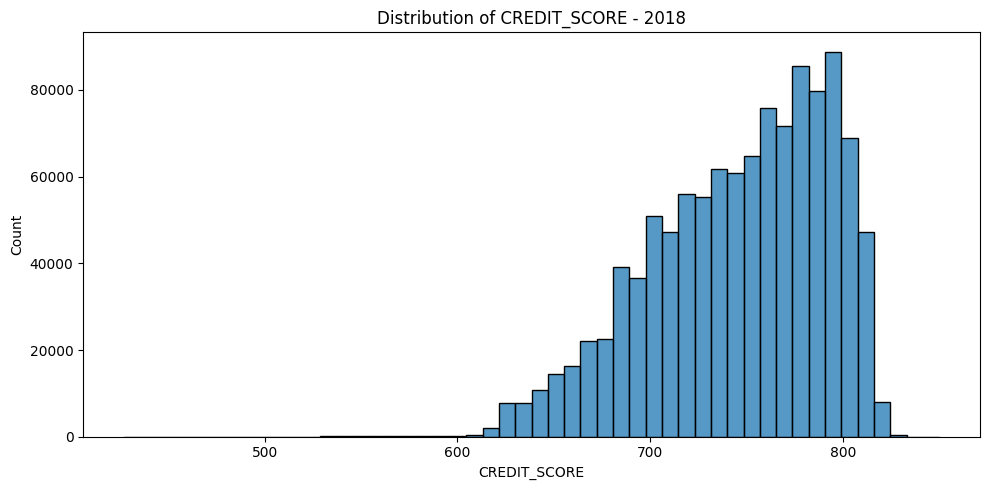

=== ORIGINAL_INTEREST_RATE ===


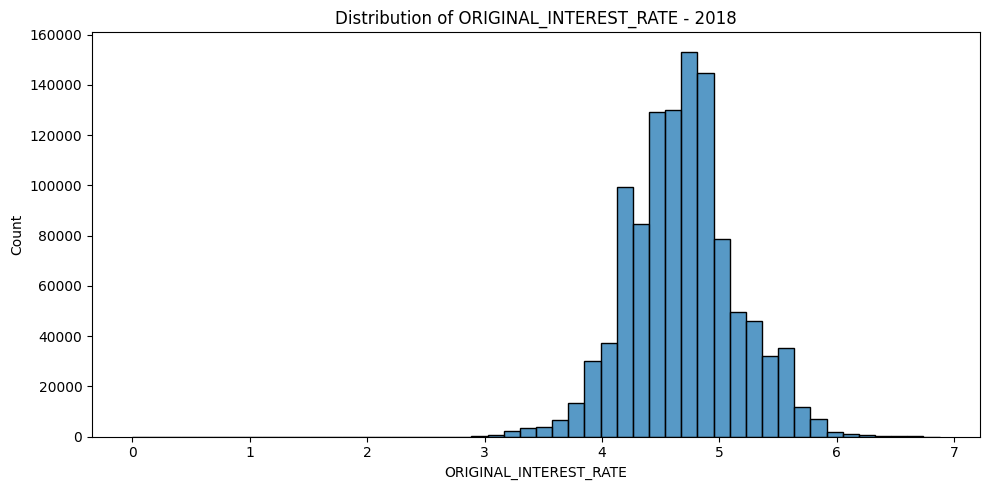

=== ORIGINAL_UPB ===


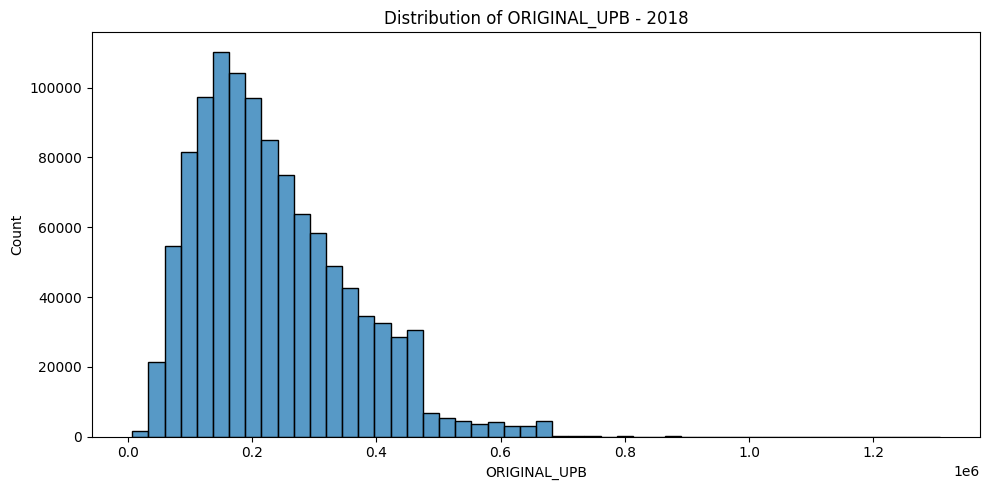

=== ORIGINAL_DTI ===


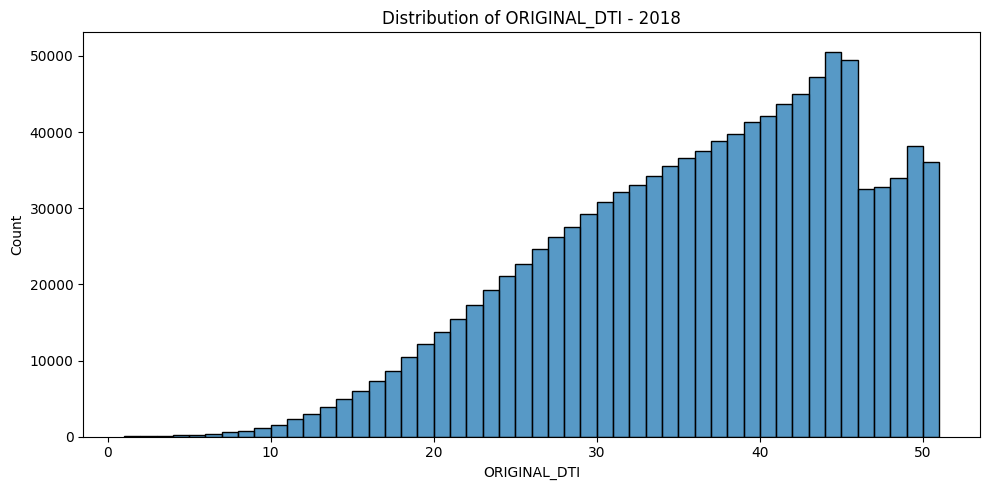

=== ORIGINAL_LTV ===


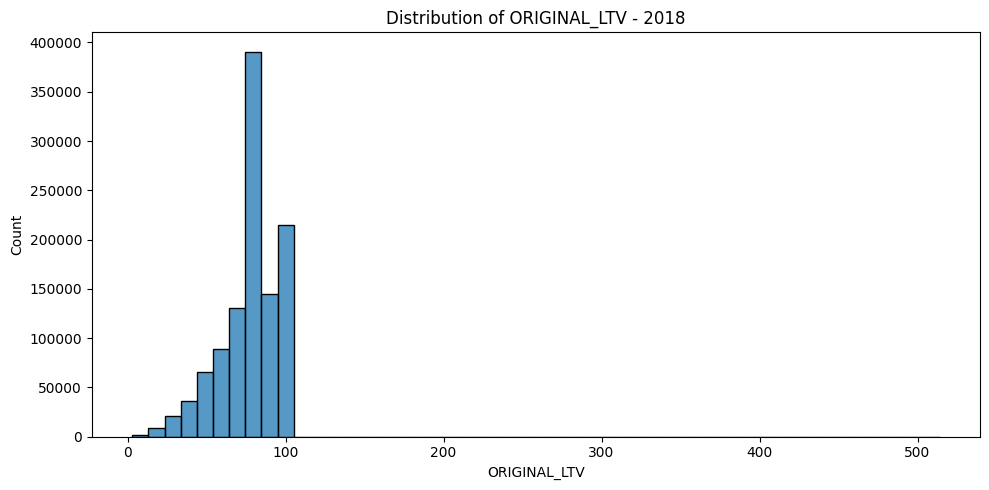

In [27]:
hystogram_columns=["credit_score", "original_interest_rate", "original_upb", "original_dti", "original_ltv"]

for column in hystogram_columns:
  tag_name=column.upper()
  print(f"=== {tag_name} ===")
  fig, ax = plt.subplots(figsize=(10, 5))

  sns.histplot(data=df_eda, x=column, bins=50, ax=ax)

  ax.set_title(f"Distribution of {tag_name} - {year}")
  ax.set_xlabel(f"{tag_name}")
  ax.set_ylabel("Count")

  plt.tight_layout()
  plt.show()

=== LOAN_PURPOSE ===


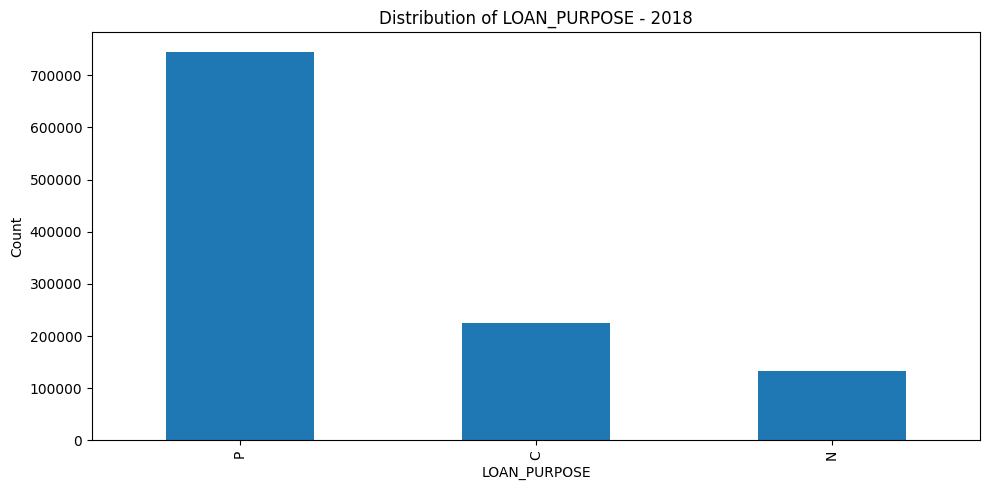

=== CHANNEL ===


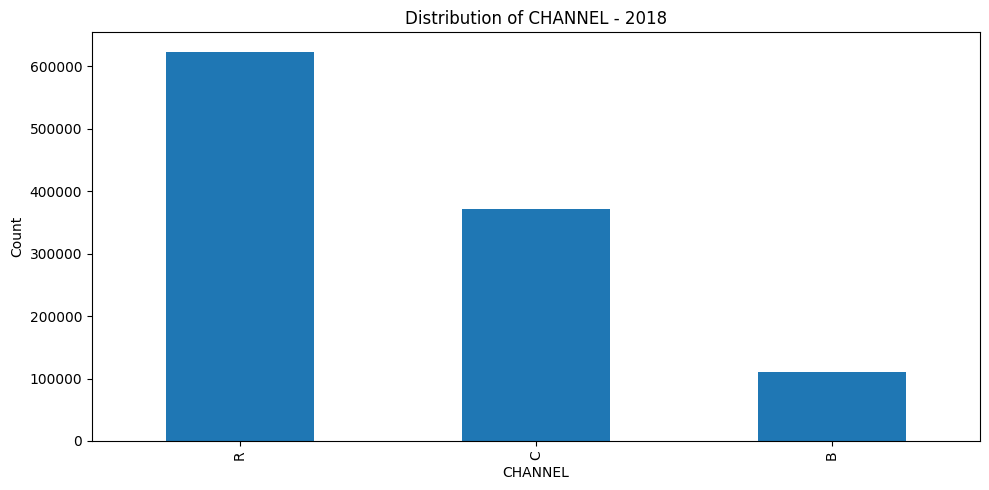

=== OCCUPANCY_STATUS ===


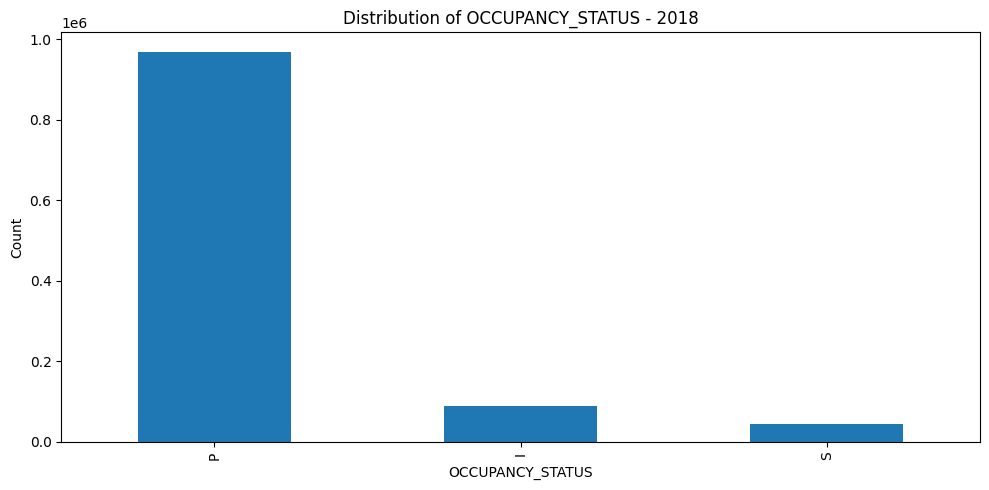

=== PROPERTY_TYPE ===


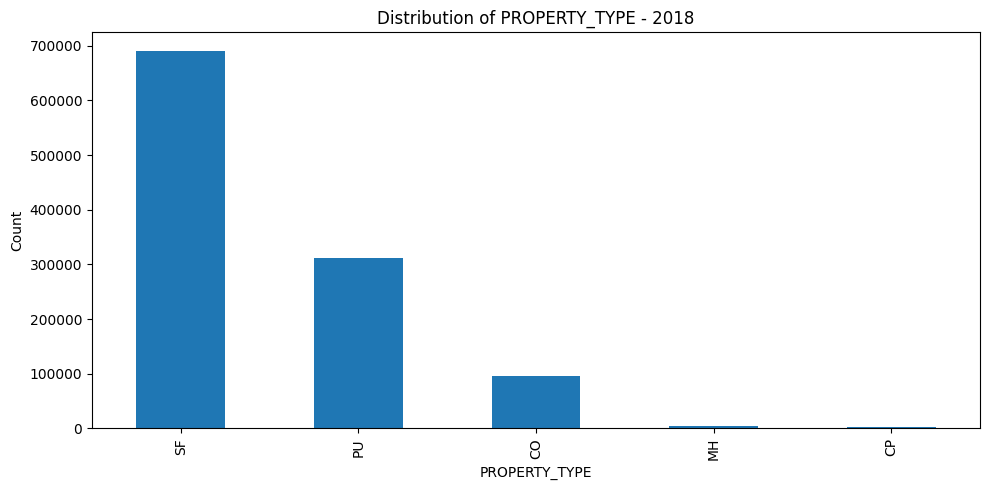

In [29]:
barplot_columns=["loan_purpose", "channel", "occupancy_status", "property_type"]

for column in barplot_columns:
  tag_name=column.upper()
  print(f"=== {tag_name} ===")
  fig, ax = plt.subplots(figsize=(10, 5))

  df_eda[column].value_counts().plot(kind="bar", ax=ax)

  ax.set_title(f"Distribution of {tag_name} - {year}")
  ax.set_xlabel(f"{tag_name}")
  ax.set_ylabel("Count")

  plt.tight_layout()
  plt.show()



Bivariate Analysis..

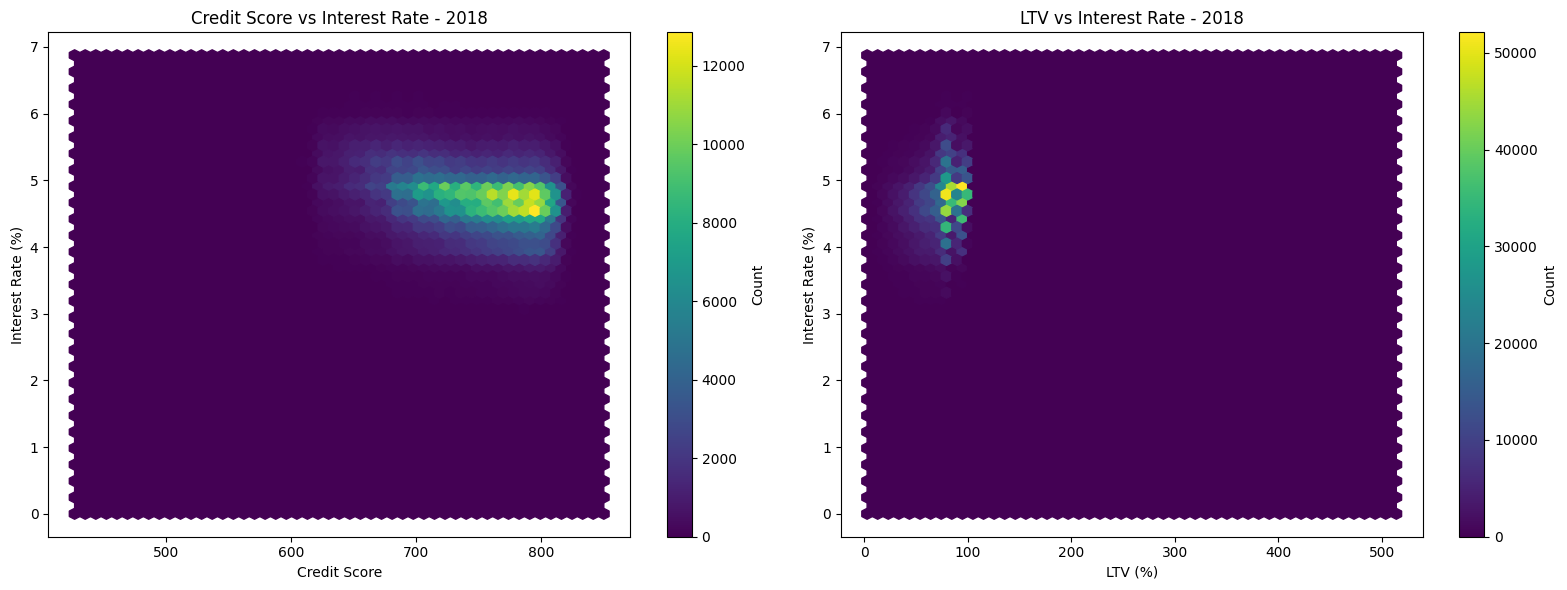

In [35]:

mask = df_eda[["credit_score", "original_interest_rate"]].dropna()


fig, axes = plt.subplots(1, 2, figsize=(16, 6))


# Credit Score vs Interest Rate
axes[0].hexbin(
    mask["credit_score"],
    mask["original_interest_rate"],
    gridsize=50,
)
axes[0].set_title(f"Credit Score vs Interest Rate - {year}")
axes[0].set_xlabel("Credit Score")
axes[0].set_ylabel("Interest Rate (%)")
fig.colorbar(axes[0].collections[0], ax=axes[0], label="Count")



mask2 = df_eda[["original_ltv", "original_interest_rate"]].dropna()


#LTV vs Interest Rate
axes[1].hexbin(
    mask2["original_ltv"],
    mask2["original_interest_rate"],
    gridsize=50,

)
axes[1].set_title(f"LTV vs Interest Rate - {year}")
axes[1].set_xlabel("LTV (%)")
axes[1].set_ylabel("Interest Rate (%)")
fig.colorbar(axes[1].collections[0], ax=axes[1], label="Count")

plt.tight_layout()
plt.show()

Multivariate Analysis - correlation

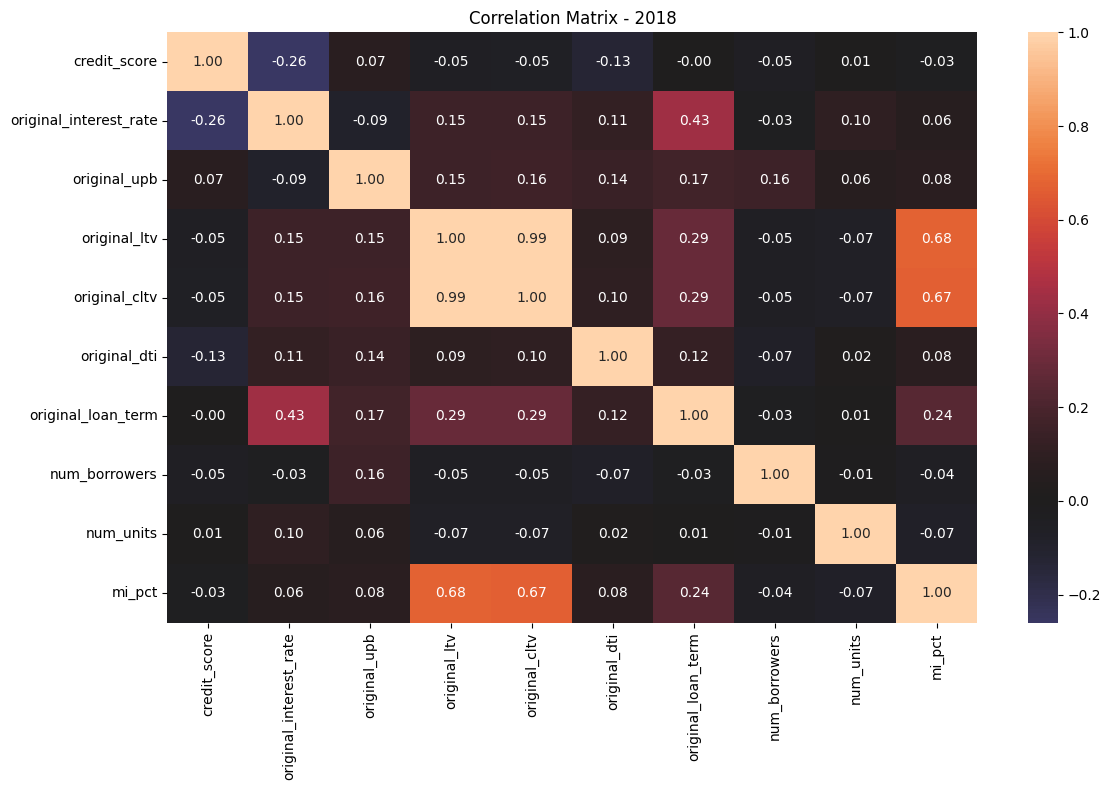

In [36]:
num_cols = [
    "credit_score", "original_interest_rate", "original_upb",
    "original_ltv", "original_cltv", "original_dti",
    "original_loan_term", "num_borrowers", "num_units", "mi_pct"
]


corr_matrix = df_eda[num_cols].corr()


fig, ax = plt.subplots(figsize=(12, 8))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    center=0,
    ax=ax
)

ax.set_title(f"Correlation Matrix - {year}")
plt.tight_layout()
plt.show()

Cross-year Analysis ...


/tmp/ipykernel_599/2725591807.py:4: DtypeWarning: Columns (26,28) have mixed types. Specify dtype option on import or set low_memory=False.
  df= pd.read_csv(out_path)


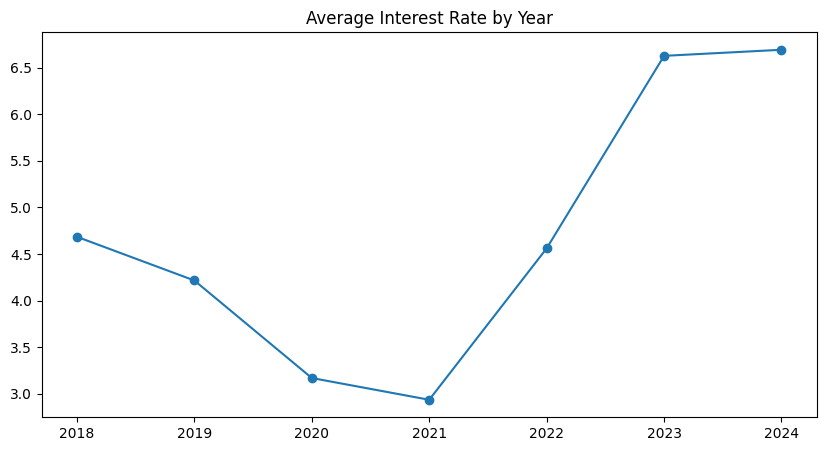

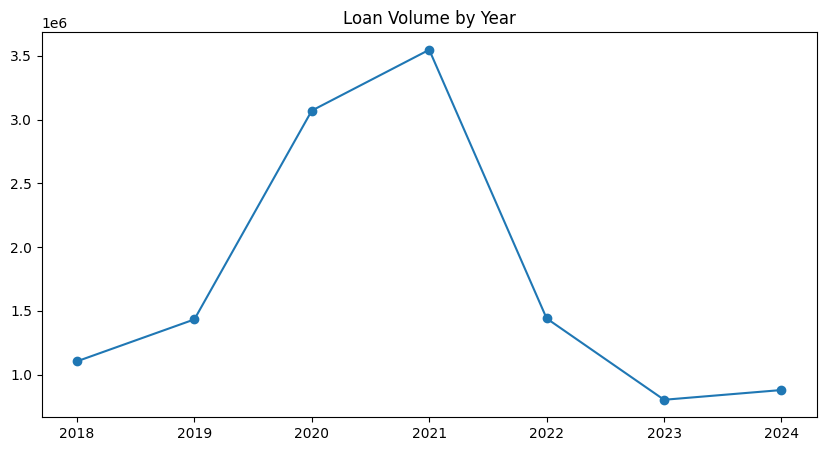

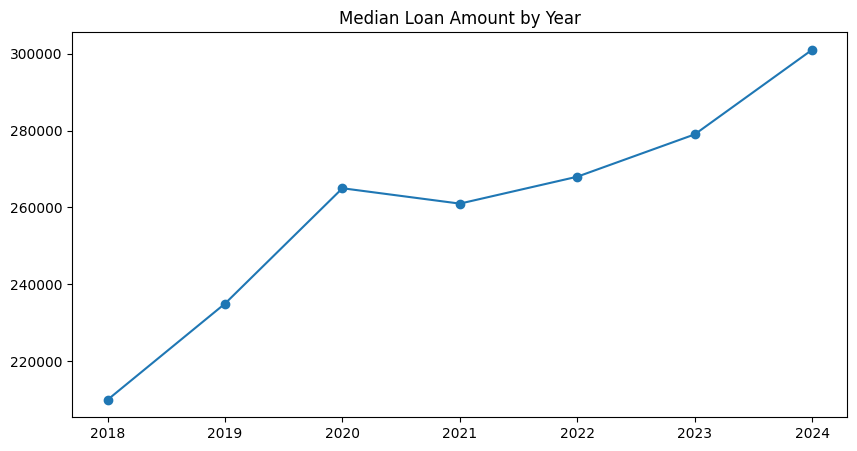

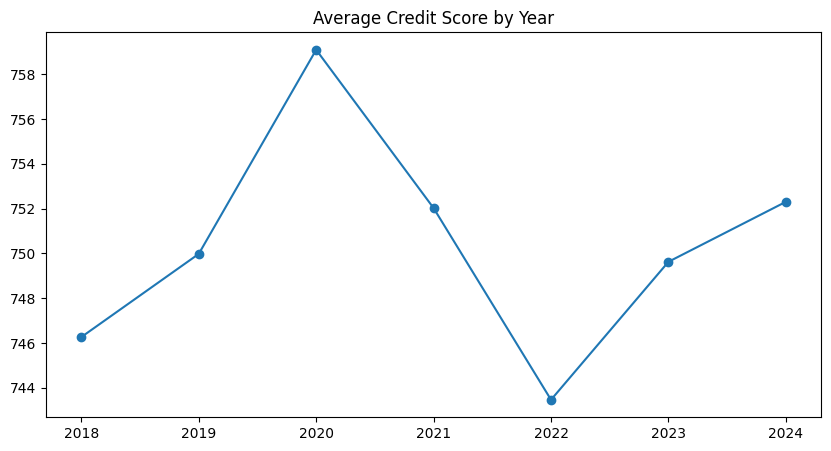

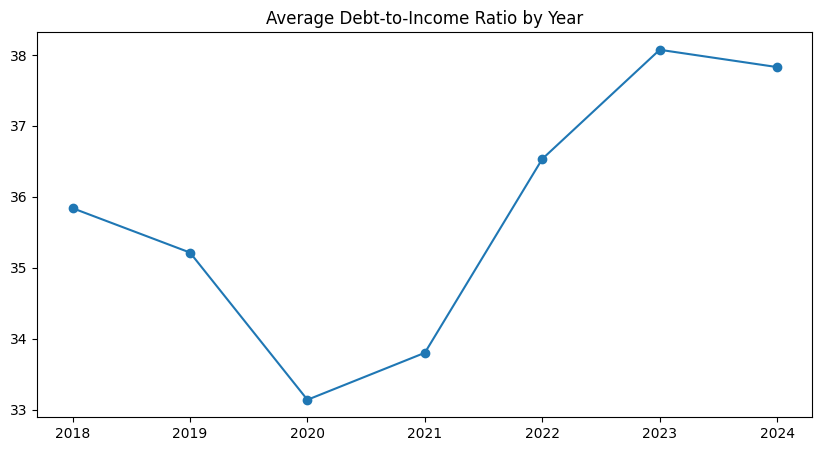

In [31]:
rows = []
for year in available_years:
    out_path = os.path.join(output_dir, f"freddie_{year}.csv")
    df= pd.read_csv(out_path)
    df = clean_freddie(df)

    rows.append({
        "year":             year,
        "mean_rate":        df["original_interest_rate"].mean(),
        "volume":           len(df),
        "median_upb":       df["original_upb"].median(),
        "mean_credit":      df["credit_score"].mean(),
        "mean_dti":         df["original_dti"].mean(),
    })

summary = pd.DataFrame(rows)

dictColumnTag={ "mean_rate": "Average Interest Rate by Year",
        "volume":      "Loan Volume by Year",
        "median_upb":  "Median Loan Amount by Year",
        "mean_credit":     "Average Credit Score by Year",
        "mean_dti":               "Average Debt-to-Income Ratio by Year" }

for column in dictColumnTag.keys():
  fig, ax = plt.subplots(figsize=(10, 5))
  ax.plot(summary["year"], summary[column], marker="o")
  ax.set_title(dictColumnTag[column])
  plt.show()


### **PERFORMANCE**

In [3]:
PERF_COLS_KEEP = [
    "loan_sequence_number",
      "current_upb",
    "monthly_reporting_period",
    "current_loan_delinquency_status",
    "loan_age",
    "estimated_ltv",
    "modification_flag",
     "current_interest_rate",

]

FREDDIE_PERF_COLS = [
    "loan_sequence_number",
    "monthly_reporting_period",
    "current_upb",
    "current_loan_delinquency_status",
    "loan_age",
    "remaining_months_to_maturity",
    "defect_settlement_date",
    "modification_flag",
    "zero_balance_code",
    "zero_balance_effective_date",
    "current_interest_rate",
    "current_non_interest_bearing_upb",
    "due_date_last_paid_installment",
    "mi_recoveries",
    "net_sale_proceeds",
    "non_mi_recoveries",
    "total_expenses",
    "legal_costs",
    "maintenance_costs",
    "taxes_insurance",
    "misc_expenses",
    "actual_loss",
    "cumulative_modification_cost",
    "step_modification_flag",
    "payment_deferral_flag",
    "estimated_ltv",
    "zero_balance_removal_upb",
    "delinquent_accrued_interest",
    "delinquency_due_to_disaster",
    "borrower_assistance_status",
    "current_month_modification_cost",
    "interest_bearing_upb",
]

# Extract performance files
def extract_performance_zips(year, freddie_dir, perf_local):
    zip_pattern_sub  = os.path.join(freddie_dir, f"historical_data_{year}", f"historical_data_{year}Q*.zip")
    zip_pattern_flat = os.path.join(freddie_dir, f"historical_data_{year}Q*.zip")

    zip_files = glob.glob(zip_pattern_sub) or glob.glob(zip_pattern_flat)

    if not zip_files:
        raise FileNotFoundError(f"No zip files found for {year}." )

    extracted = []

    # Iterates over zip files in alphabetical/chronological order (Q1→Q2→Q3→Q4)
    for zpath in sorted(zip_files):
        # Opens the zip in read "r" mode
        with zipfile.ZipFile(zpath, "r") as z:
            time_files = [f for f in z.namelist() if "time" in f.lower() and f.endswith(".txt")]
            if not time_files:
                continue
            for tf in time_files:
                dest = os.path.join(perf_local, os.path.basename(tf))
                # Opens the file inside the zip and writes "wb" it to disk
                if not os.path.exists(dest):
                    with z.open(tf) as src, open(dest, "wb") as dst:
                        shutil.copyfileobj(src, dst)
                extracted.append(dest)

    if not extracted:
        raise RuntimeError(f"No TIME files extracted for {year}.")
    return extracted

def load_and_prepare_performance(txt_files, year, output_dir):
    out_path = os.path.join(output_dir, f"freddie_performance_{year}.csv")

    first_write = True
    total_rows = 0

    for f in txt_files:
        for chunk in pd.read_csv(
            f, sep="|", header=None,
            names=FREDDIE_PERF_COLS,
            usecols=[FREDDIE_PERF_COLS.index(c) for c in PERF_COLS_KEEP],
            dtype=str, low_memory=False,
            chunksize=500_000
        ):
            chunk.to_csv(
                out_path,
                mode="w" if first_write else "a",
                header=first_write,
                index=False
            )
            total_rows += len(chunk)
            first_write = False
            del chunk
            gc.collect()

    print(f"  {year}: {total_rows:,} records → saved to {out_path}")


drive_root="/content/drive/MyDrive/thesis_data"
freddie_dir   = os.path.join(drive_root, "freddie")
perf_local = os.path.join(drive_root, "perf_local_tmp")
output_dir    = os.path.join(drive_root, "output")

# Creates output folders if they don't exist yet.
os.makedirs(output_dir,    exist_ok=True)
os.makedirs(perf_local, exist_ok=True)

available_years=[2018,2019,2020,2021,2022,2023,2024]
for year in available_years:
    txt_files = extract_performance_zips(year, freddie_dir, perf_local)
    load_and_prepare_performance(txt_files, year, output_dir)

    for f in txt_files:
        os.remove(f)
    gc.collect()


  2018: 51,103,837 records → saved to /content/drive/MyDrive/thesis_data/output/freddie_performance_2018.csv
  2019: 66,393,392 records → saved to /content/drive/MyDrive/thesis_data/output/freddie_performance_2019.csv
  2020: 187,641,606 records → saved to /content/drive/MyDrive/thesis_data/output/freddie_performance_2020.csv
  2021: 188,696,375 records → saved to /content/drive/MyDrive/thesis_data/output/freddie_performance_2021.csv
  2022: 58,315,049 records → saved to /content/drive/MyDrive/thesis_data/output/freddie_performance_2022.csv
  2023: 22,771,770 records → saved to /content/drive/MyDrive/thesis_data/output/freddie_performance_2023.csv
  2024: 14,226,973 records → saved to /content/drive/MyDrive/thesis_data/output/freddie_performance_2024.csv


Analyzing the Data and Checking Missing Values...

In [3]:
drive_root="/content/drive/MyDrive/thesis_data"
output_dir    = os.path.join(drive_root, "output")


available_years=[2018,2019,2020,2021,2022,2023,2024]
for year in available_years:
    print(f"============ Analyzing file related to {year} ============ ")
    out_path = os.path.join(output_dir, f"freddie_performance_{year}.csv")

    # Accumula statistiche chunk by chunk
    total_rows = 0
    null_counts = None
    dtypes      = None
    numeric_stats = []

    for chunk in pd.read_csv(out_path, chunksize=500_000, low_memory=False):

        # Pulizia
        chunk["estimated_ltv"] = pd.to_numeric(chunk["estimated_ltv"], errors="coerce")
        chunk["estimated_ltv"] = chunk["estimated_ltv"].replace(999, np.nan)

        total_rows += len(chunk)

        # Dtypes (prendi solo dal primo chunk)
        if dtypes is None:
            dtypes = chunk.dtypes

        # Missing values — accumula
        if null_counts is None:
            null_counts = chunk.isnull().sum()
        else:
            null_counts += chunk.isnull().sum()

        # Statistiche numeriche — accumula describe
        numeric_stats.append(chunk.describe().T)

        del chunk
        gc.collect()

    # Stampa risultati
    print(f"Shape: ({total_rows:,} rows x {len(dtypes)} columns)")
    print("\nData Types:")
    print(dtypes)
    print("\nMissing Values:")
    print(null_counts)
    print("\nNumeric Stats (mean across chunks):")
    combined = pd.concat(numeric_stats)
    print(combined.groupby(combined.index).mean())

    del numeric_stats, null_counts, dtypes
    gc.collect()

============ Analyzing file related to 2018 ============ 
Shape: (51,103,837 rows x 8 columns)

Data Types:
loan_sequence_number                object
monthly_reporting_period             int64
current_loan_delinquency_status     object
loan_age                             int64
modification_flag                   object
zero_balance_code                  float64
estimated_ltv                      float64
borrower_assistance_status          object
dtype: object

Missing Values:
loan_sequence_number                      0
monthly_reporting_period                  0
current_loan_delinquency_status           0
loan_age                                  0
modification_flag                  50676061
zero_balance_code                  50076846
estimated_ltv                       5136578
borrower_assistance_status         50313301
dtype: int64

Numeric Stats (mean across chunks):
                                  count           mean         std  \
estimated_ltv             446284.067961      

Univariate Analysis...

In [4]:
year=2024
drive_root="/content/drive/MyDrive/thesis_data"
output_dir    = os.path.join(drive_root, "output")
out_path = os.path.join(output_dir, f"freddie_performance_{year}.csv")
df= pd.read_csv(out_path)


print(f"Analysis related to {year}" )

/tmp/ipykernel_95034/4255952738.py:5: DtypeWarning: Columns (2,4) have mixed types. Specify dtype option on import or set low_memory=False.
  df= pd.read_csv(out_path)


Analysis related to 2024


=== Loan Age ===


Text(0.5, 1.0, 'Distribution of Max Loan Age - 2024')

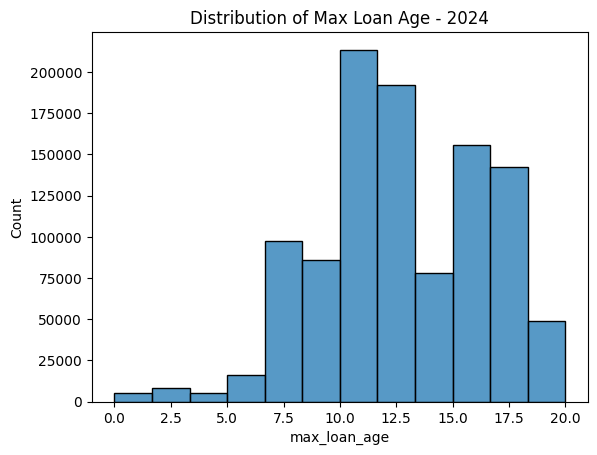

In [6]:

loan_summary = df.groupby("loan_sequence_number").agg(
    max_loan_age = ("loan_age", "max"),
    ever_delinquent = ("current_loan_delinquency_status", lambda x: (pd.to_numeric(x, errors="coerce") > 0).any()),
    zero_balance_code = ("zero_balance_code", "last"),
    max_ltv = ("estimated_ltv", "max"),
    min_ltv = ("estimated_ltv", "min"),
).reset_index()

print("=== Loan Age ===")
sns.histplot(data=loan_summary, x="max_loan_age", bins=12)
plt.title(f"Distribution of Max Loan Age - {year}")


=== Current Deliquency Status ===


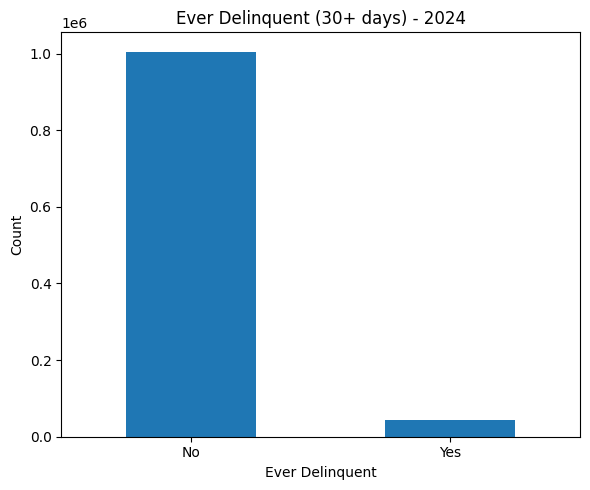

In [7]:

print("=== Current Deliquency Status ===")
fig, ax = plt.subplots(figsize=(6, 5))

loan_summary["ever_delinquent"].value_counts().plot(kind="bar", ax=ax)

ax.set_title(f"Ever Delinquent (30+ days) - {year}")
ax.set_xlabel("Ever Delinquent")
ax.set_ylabel("Count")
ax.set_xticklabels(["No", "Yes"], rotation=0)

plt.tight_layout()
plt.show()

=== Estimated LTV ===


Text(0, 0.5, 'Estimated LTV (%)')

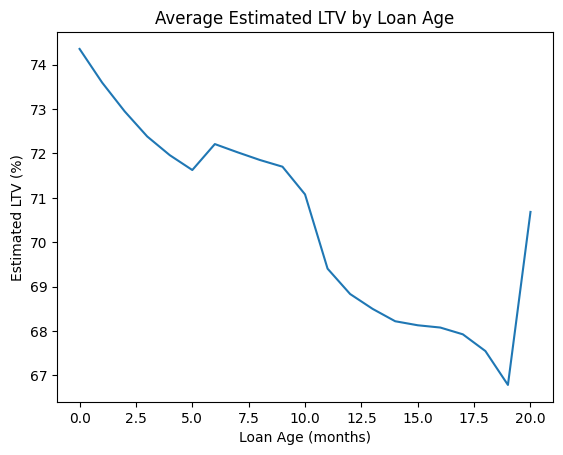

In [9]:

print("=== Estimated LTV ===")

df["estimated_ltv"] = pd.to_numeric(df["estimated_ltv"], errors="coerce")
df["estimated_ltv"] = df["estimated_ltv"].replace(999, np.nan)

# Ora riplotta
ltv_by_age = df.groupby("loan_age")["estimated_ltv"].mean()
ltv_by_age.plot()
plt.title("Average Estimated LTV by Loan Age")
plt.xlabel("Loan Age (months)")
plt.ylabel("Estimated LTV (%)")

Presence of time-varying covariate...

In [5]:

loan_summary = df.groupby("loan_sequence_number").agg(
    upb_std  = ("current_upb",           "std"),
    rate_std = ("current_interest_rate",  "std"),
    ltv_std  = ("estimated_ltv",          "std"),
).reset_index()



loan_summary["has_tvc"] = (
    (loan_summary["upb_std"]  > 0) |
    (loan_summary["rate_std"] > 0) |
    (loan_summary["ltv_std"]  > 0)
)

fig, ax = plt.subplots(figsize=(6, 5))
loan_summary["has_tvc"].value_counts()\
    .rename({True: "Variable TVC", False: "Flat TVC"})\
    .plot(kind="bar", ax=ax)

ax.set_title(f"Loans with Variable vs Flat TVC - {year}")
ax.set_ylabel("Count")
ax.set_xticklabels(["Variable TVC", "Flat TVC"], rotation=0)
plt.tight_layout()
plt.show()

KeyError: "Column(s) ['current_interest_rate', 'current_upb'] do not exist"

Cross-year analysis...

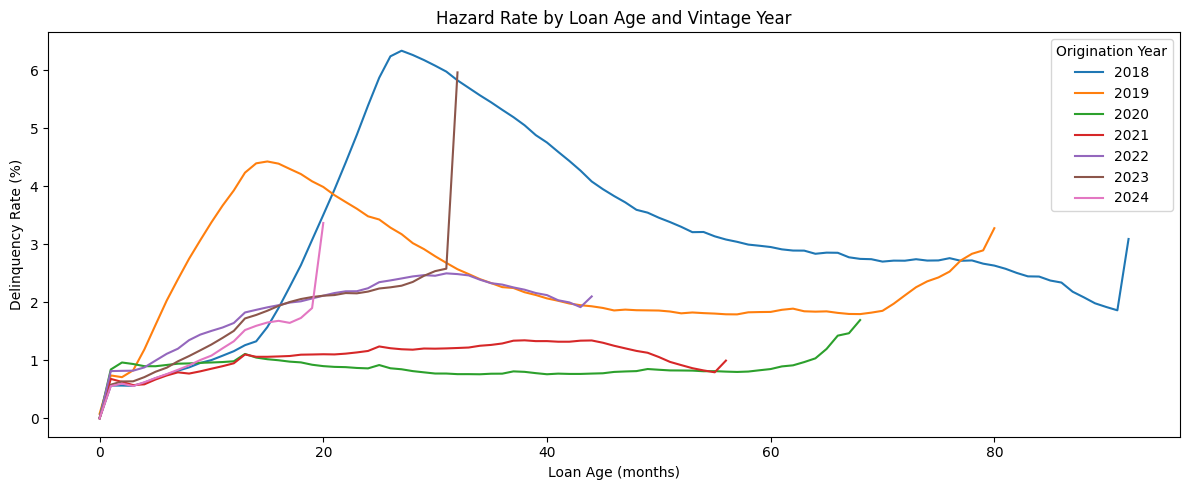

In [7]:
fig, ax = plt.subplots(figsize=(12, 5))
drive_root="/content/drive/MyDrive/thesis_data"
output_dir    = os.path.join(drive_root, "output")


available_years=[2018,2019,2020,2021,2022,2023,2024]
for year in available_years:
    out_path = os.path.join(output_dir, f"freddie_performance_{year}.csv")

    # Accumula evento e loan_age chunk by chunk
    agg = []
    for chunk in pd.read_csv(out_path,
                              usecols=["loan_age",
                                       "current_loan_delinquency_status"],
                              chunksize=500_000,
                              low_memory=False):

        chunk["event"] = (
            pd.to_numeric(chunk["current_loan_delinquency_status"],
                         errors="coerce") > 0
        ).astype(float)

        # Aggrega subito — non tenere il chunk intero
        agg.append(chunk.groupby("loan_age")["event"].agg(["sum", "count"]))
        del chunk
        gc.collect()

    # Combina i chunk aggregati
    combined = pd.concat(agg).groupby(level=0).sum()
    hazard_y = (combined["sum"] / combined["count"]) * 100
    hazard_y.plot(ax=ax, label=str(year))

    del agg, combined, hazard_y
    gc.collect()

ax.legend(title="Origination Year")
ax.set_title("Hazard Rate by Loan Age and Vintage Year")
ax.set_xlabel("Loan Age (months)")
ax.set_ylabel("Delinquency Rate (%)")
plt.tight_layout()
plt.show()

##**EDA 2** - HMDA (pre-match)

Load data...

In [3]:
HMDA_EDA_COLS = [
    # Identificativo
    "activity_year",
    # Demografiche
    "derived_race", "derived_ethnicity", "derived_sex",
    "applicant_age", "income", "applicant_age_above_62",
    # Loan
    "loan_amount", "loan_type", "loan_purpose",
    "action_taken", "interest_rate", "loan_term",
    "total_units", "occupancy_type",
    # Rischio
    "debt_to_income_ratio", "combined_loan_to_value_ratio",
    # Geografiche
    "state_code", "derived_msa_md", "county_code",
    # Lender
    "purchaser_type", "derived_loan_product_type",
]

CHUNK_SIZE= 200_000

def find_hmda_file(year, hmda_dir):
    path = os.path.join(hmda_dir, f"{year}_public_lar.csv")
    if not os.path.exists(path):
        raise FileNotFoundError(f"No HMDA file found for {year}")
    return path


# Filter and prepare one chunck of HMDA for merging.
def save_hmda_year_eda(year, hmda_dir, output_dir):
    hmda_path = find_hmda_file(year, hmda_dir)
    out_path  = os.path.join(output_dir, f"hmda_{year}.csv")

    first_write = True
    total_rows  = 0

    for chunk in pd.read_csv(hmda_path, dtype=str,
                         chunksize=CHUNK_SIZE, low_memory=False,
                         usecols=lambda c: c.replace("-","_") in HMDA_EDA_COLS):

        chunk.rename(columns=lambda c: c.replace("-", "_"), inplace=True)

        chunk.to_csv(
            out_path,
            mode="w" if first_write else "a",
            header=first_write,
            index=False
        )
        total_rows += len(chunk)
        first_write = False
        del chunk
        gc.collect()

    print(f"  {year}: {total_rows:,} rows → saved to {out_path}")



drive_root="/content/drive/MyDrive/thesis_data"
hmda_dir = os.path.join(drive_root, "hmda")
output_dir    = os.path.join(drive_root, "output")

# Creates output folders if they don't exist yet.
os.makedirs(output_dir,    exist_ok=True)


#available_years=[2018,2019,2020,2021,2022,2023,2024]
available_years=[2018,2019]
for year in available_years:
    save_hmda_year_eda(year, hmda_dir, output_dir)
    gc.collect()



  2018: 15,119,651 rows → saved to /content/drive/MyDrive/thesis_data/output/hmda_2018.csv
  2019: 17,545,457 rows → saved to /content/drive/MyDrive/thesis_data/output/hmda_2019.csv


Analyzing the Data and Checking Missing Values...

In [4]:
drive_root="/content/drive/MyDrive/thesis_data"
output_dir    = os.path.join(drive_root, "output")



for year in available_years:
    print(f"============ Analyzing file related to {year} ============ ")
    out_path = os.path.join(output_dir, f"freddie_performance_{year}.csv")

    total_rows = 0
    null_counts = None
    dtypes      = None
    numeric_stats = []

    for chunk in pd.read_csv(out_path, chunksize=500_000, low_memory=False):

        total_rows += len(chunk)

        if dtypes is None:
            dtypes = chunk.dtypes

        if null_counts is None:
            null_counts = chunk.isnull().sum()
        else:
            null_counts += chunk.isnull().sum()
        numeric_stats.append(chunk.describe().T)

        del chunk
        gc.collect()

    print(f"Shape: ({total_rows:,} rows x {len(dtypes)} columns)")
    print("\nData Types:")
    print(dtypes)
    print("\nMissing Values:")
    print(null_counts)
    print("\nNumeric Stats (mean across chunks):")
    combined = pd.concat(numeric_stats)
    print(combined.groupby(combined.index).mean())

    del numeric_stats, null_counts, dtypes
    gc.collect()

============ Analyzing file related to 2018 ============ 
Shape: (51,103,837 rows x 8 columns)

Data Types:
loan_sequence_number                object
monthly_reporting_period             int64
current_loan_delinquency_status     object
loan_age                             int64
modification_flag                   object
zero_balance_code                  float64
estimated_ltv                        int64
borrower_assistance_status          object
dtype: object

Missing Values:
loan_sequence_number                      0
monthly_reporting_period                  0
current_loan_delinquency_status           0
loan_age                                  0
modification_flag                  50676061
zero_balance_code                  50076846
estimated_ltv                             0
borrower_assistance_status         50313301
dtype: int64

Numeric Stats (mean across chunks):
                                  count           mean         std  \
estimated_ltv             496153.757282     1

Univariate Analysis...

In [2]:
year=2018
drive_root="/content/drive/MyDrive/thesis_data"
output_dir    = os.path.join(drive_root, "output")

out_path = os.path.join(output_dir, f"hmda_{year}.csv")
df= pd.read_csv(out_path)

print(f"Analysis related to {year}" )

/tmp/ipykernel_9617/2308277003.py:6: DtypeWarning: Columns (3,13,14,16,18) have mixed types. Specify dtype option on import or set low_memory=False.
  df= pd.read_csv(out_path)


Analysis related to 2018


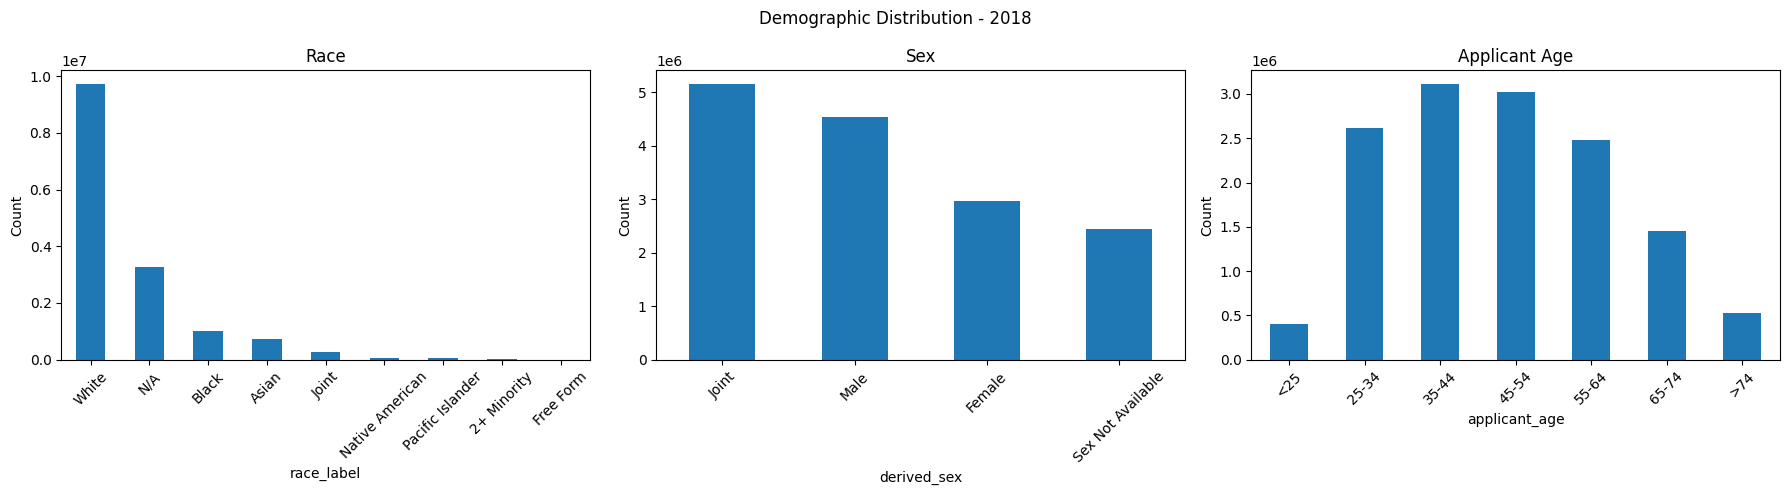

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f"Demographic Distribution - {year}")

# Race
race_map = {
    "White":                                          "White",
    "Black or African American":                      "Black",
    "Asian":                                          "Asian",
    "Joint":                                          "Joint",
    "Race Not Available":                             "N/A",
    "American Indian or Alaska Native":               "Native American",
    "Native Hawaiian or Other Pacific Islander":      "Pacific Islander",
    "2 or more minority races":                       "2+ Minority",
    "Free Form Text Only":                            "Free Form",
}

df["race_label"] = df["derived_race"].map(race_map).fillna(df["derived_race"])
df["race_label"].value_counts().plot(kind="bar", ax=axes[0])
axes[0].set_title("Race")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=45)

# Sex
df["derived_sex"].value_counts().plot(kind="bar", ax=axes[1])
axes[1].set_title("Sex")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis="x", rotation=45)

# Age
age_order = ["<25", "25-34", "35-44", "45-54", "55-64", "65-74", ">74"]
age_counts = df["applicant_age"].value_counts()
age_counts  = age_counts.reindex([a for a in age_order if a in age_counts.index])
age_counts.plot(kind="bar", ax=axes[2])
axes[2].set_title("Applicant Age")
axes[2].set_ylabel("Count")
axes[2].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

Bivariate Analysis...

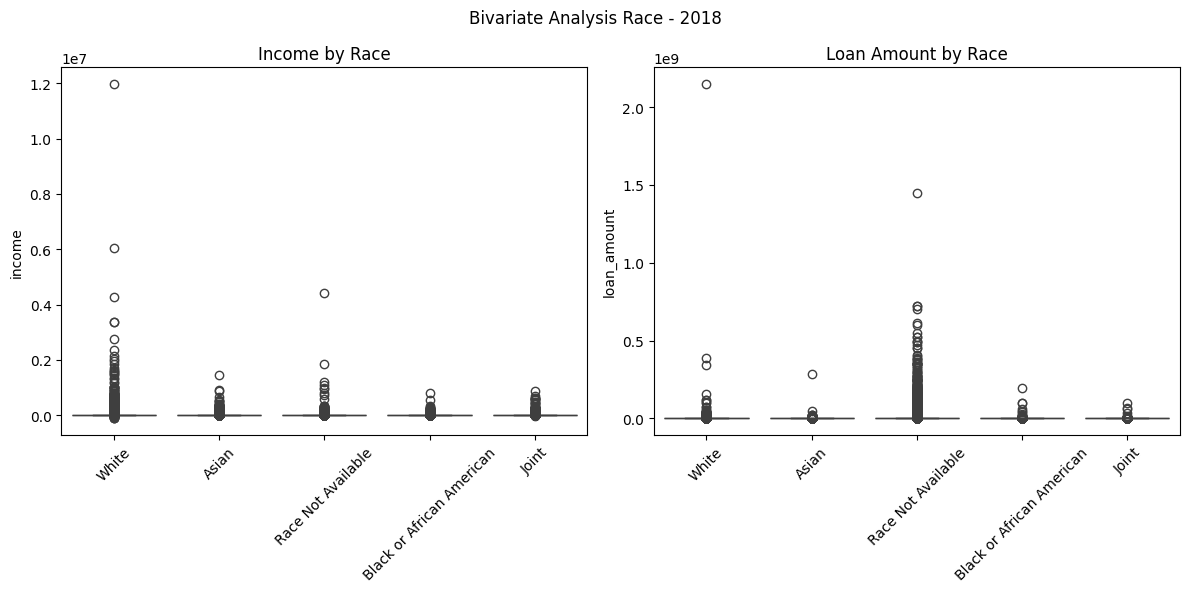

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
fig.suptitle(f"Bivariate Analysis Race - {year}")

df["loan_amount"] = pd.to_numeric(df["loan_amount"], errors="coerce")
df["income"]      = pd.to_numeric(df["income"],      errors="coerce")



top_races = df["derived_race"].value_counts().head(5).index
sns.boxplot(
    data=df[df["derived_race"].isin(top_races)],
    x="derived_race", y="income",
    ax=axes[0]
)
axes[0].set_title("Income by Race")
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=45)


sns.boxplot(
    data=df[df["derived_race"].isin(top_races)],
    x="derived_race", y="loan_amount",
    ax=axes[1]
)
axes[1].set_title("Loan Amount by Race")
axes[1].set_xlabel("")
axes[1].tick_params(axis="x", rotation=45)


plt.tight_layout()
plt.show()


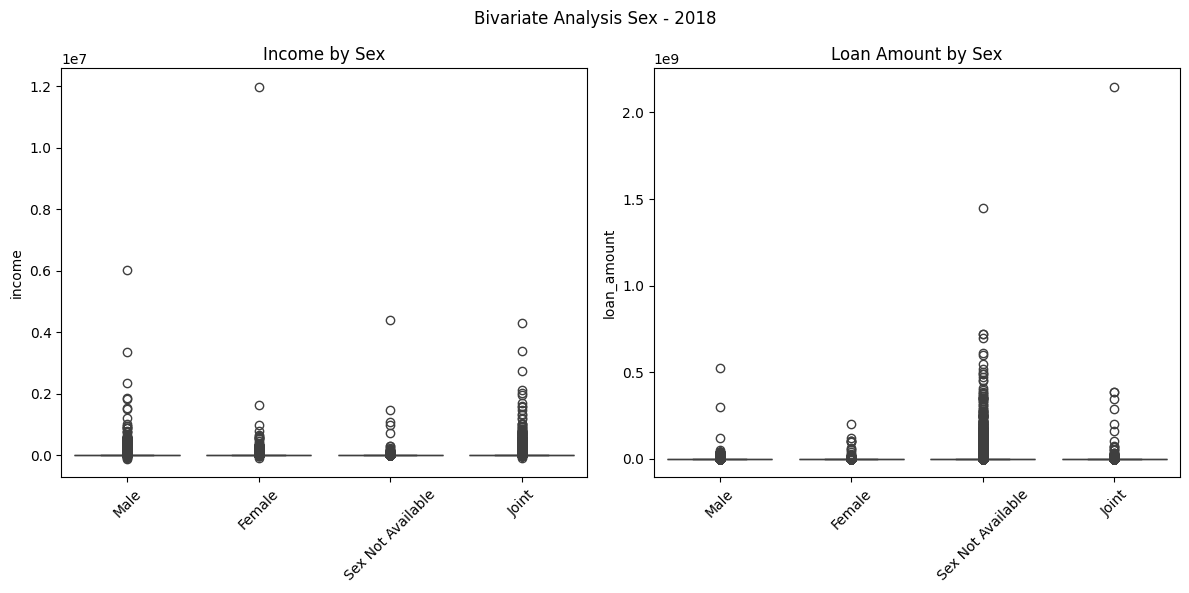

5435

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
fig.suptitle(f"Bivariate Analysis Sex - {year}")

df["loan_amount"] = pd.to_numeric(df["loan_amount"], errors="coerce")
df["income"]      = pd.to_numeric(df["income"],      errors="coerce")

sns.boxplot(
    data=df,
    x="derived_sex", y="income",
    ax=axes[0]
)
axes[0].set_title("Income by Sex")
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=45)

sns.boxplot(
    data=df,
    x="derived_sex", y="loan_amount",
    ax=axes[1]
)
axes[1].set_title("Loan Amount by Sex")
axes[1].set_xlabel("")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

gc.collect()

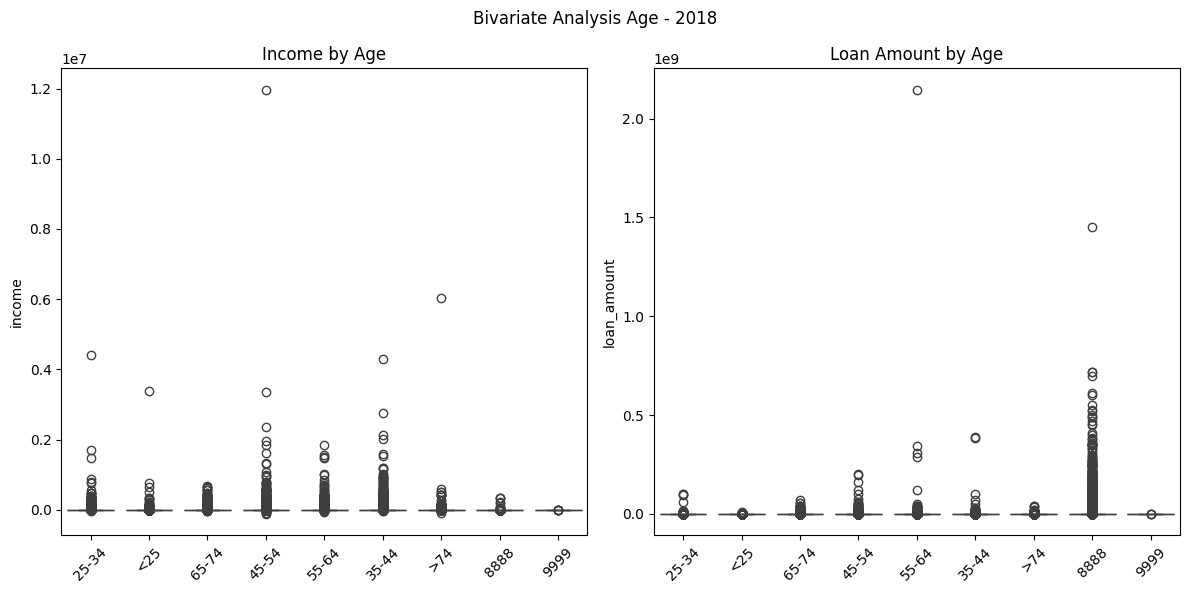

13873

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
fig.suptitle(f"Bivariate Analysis Age - {year}")

df["loan_amount"] = pd.to_numeric(df["loan_amount"], errors="coerce")
df["income"]      = pd.to_numeric(df["income"],      errors="coerce")

sns.boxplot(
    data=df,
    x="applicant_age", y="income",
    ax=axes[0]
)
axes[0].set_title("Income by Age")
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=45)

sns.boxplot(
    data=df,
    x="applicant_age", y="loan_amount",
    ax=axes[1]
)
axes[1].set_title("Loan Amount by Age")
axes[1].set_xlabel("")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

gc.collect()

Cross-year Analysis...

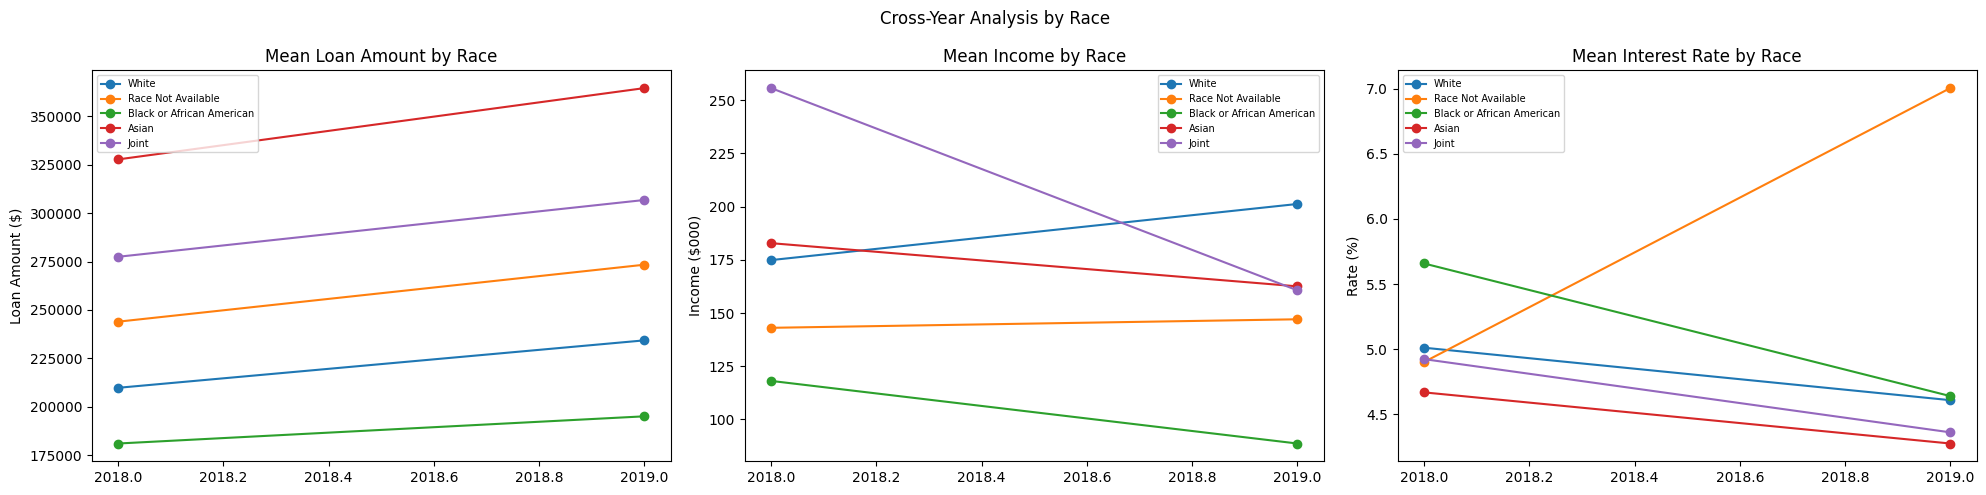

11162

In [10]:
rows = []
available_years = [2018, 2019]

drive_root = "/content/drive/MyDrive/thesis_data"
output_dir = os.path.join(drive_root, "output")

COLS_NEEDED = ["derived_race", "loan_amount", "income", "interest_rate"]

for y in available_years:
    out_path = os.path.join(output_dir, f"hmda_{y}.csv")

    df_y = pd.read_csv(out_path, usecols=COLS_NEEDED, low_memory=False)

    df_y["loan_amount"]   = pd.to_numeric(df_y["loan_amount"],   errors="coerce")
    df_y["income"]        = pd.to_numeric(df_y["income"],        errors="coerce")
    df_y["interest_rate"] = pd.to_numeric(df_y["interest_rate"], errors="coerce")
    df_y = df_y[(df_y["income"] > 0) & (df_y["loan_amount"] > 0)]

    top_races = df_y["derived_race"].value_counts().head(5).index
    for race in top_races:
        sub = df_y[df_y["derived_race"] == race]
        rows.append({
            "year":        y,
            "race":        race,
            "mean_loan":   sub["loan_amount"].mean(),
            "mean_income": sub["income"].mean(),
            "mean_rate":   sub["interest_rate"].mean(),
        })
    del df_y, sub; gc.collect()

cross_df = pd.DataFrame(rows)

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
fig.suptitle("Cross-Year Analysis by Race")

for race in cross_df["race"].unique():
    sub = cross_df[cross_df["race"] == race]
    axes[0].plot(sub["year"], sub["mean_loan"],   marker="o", label=race)
    axes[1].plot(sub["year"], sub["mean_income"], marker="o", label=race)
    axes[2].plot(sub["year"], sub["mean_rate"],   marker="o", label=race)

axes[0].set_title("Mean Loan Amount by Race")
axes[0].set_ylabel("Loan Amount ($)")
axes[0].legend(fontsize=7)

axes[1].set_title("Mean Income by Race")
axes[1].set_ylabel("Income ($000)")
axes[1].legend(fontsize=7)

axes[2].set_title("Mean Interest Rate by Race")
axes[2].set_ylabel("Rate (%)")
axes[2].legend(fontsize=7)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, "hmda_crossyear_race.png"), dpi=150)
plt.show()

del cross_df; gc.collect()

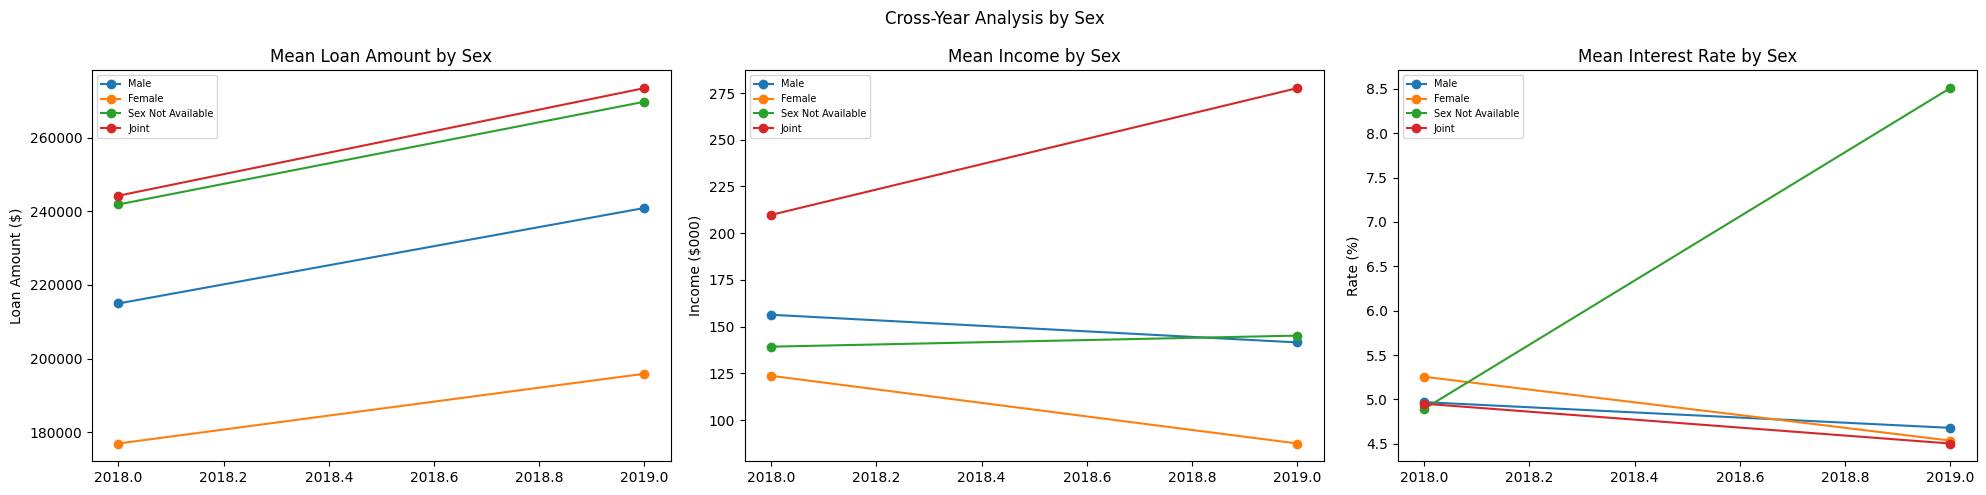

12462

In [9]:
rows_sex = []

COLS_NEEDED_SEX = ["derived_sex", "loan_amount", "income", "interest_rate"]

for y in available_years:
    out_path = os.path.join(output_dir, f"hmda_{y}.csv")

    df_y = pd.read_csv(out_path, usecols=COLS_NEEDED_SEX, low_memory=False)

    df_y["loan_amount"]   = pd.to_numeric(df_y["loan_amount"],   errors="coerce")
    df_y["income"]        = pd.to_numeric(df_y["income"],        errors="coerce")
    df_y["interest_rate"] = pd.to_numeric(df_y["interest_rate"], errors="coerce")
    df_y = df_y[(df_y["income"] > 0) & (df_y["loan_amount"] > 0)]

    for sex in df_y["derived_sex"].dropna().unique():
        sub = df_y[df_y["derived_sex"] == sex]
        rows_sex.append({
            "year":        y,
            "sex":         sex,
            "mean_loan":   sub["loan_amount"].mean(),
            "mean_income": sub["income"].mean(),
            "mean_rate":   sub["interest_rate"].mean(),
        })
    del df_y, sub; gc.collect()

cross_sex = pd.DataFrame(rows_sex)

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
fig.suptitle("Cross-Year Analysis by Sex")

for sex in cross_sex["sex"].unique():
    sub = cross_sex[cross_sex["sex"] == sex]
    axes[0].plot(sub["year"], sub["mean_loan"],   marker="o", label=sex)
    axes[1].plot(sub["year"], sub["mean_income"], marker="o", label=sex)
    axes[2].plot(sub["year"], sub["mean_rate"],   marker="o", label=sex)

axes[0].set_title("Mean Loan Amount by Sex")
axes[0].set_ylabel("Loan Amount ($)")
axes[0].legend(fontsize=7)

axes[1].set_title("Mean Income by Sex")
axes[1].set_ylabel("Income ($000)")
axes[1].legend(fontsize=7)

axes[2].set_title("Mean Interest Rate by Sex")
axes[2].set_ylabel("Rate (%)")
axes[2].legend(fontsize=7)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, "hmda_crossyear_sex.png"), dpi=150)
plt.show()

del cross_sex; gc.collect()

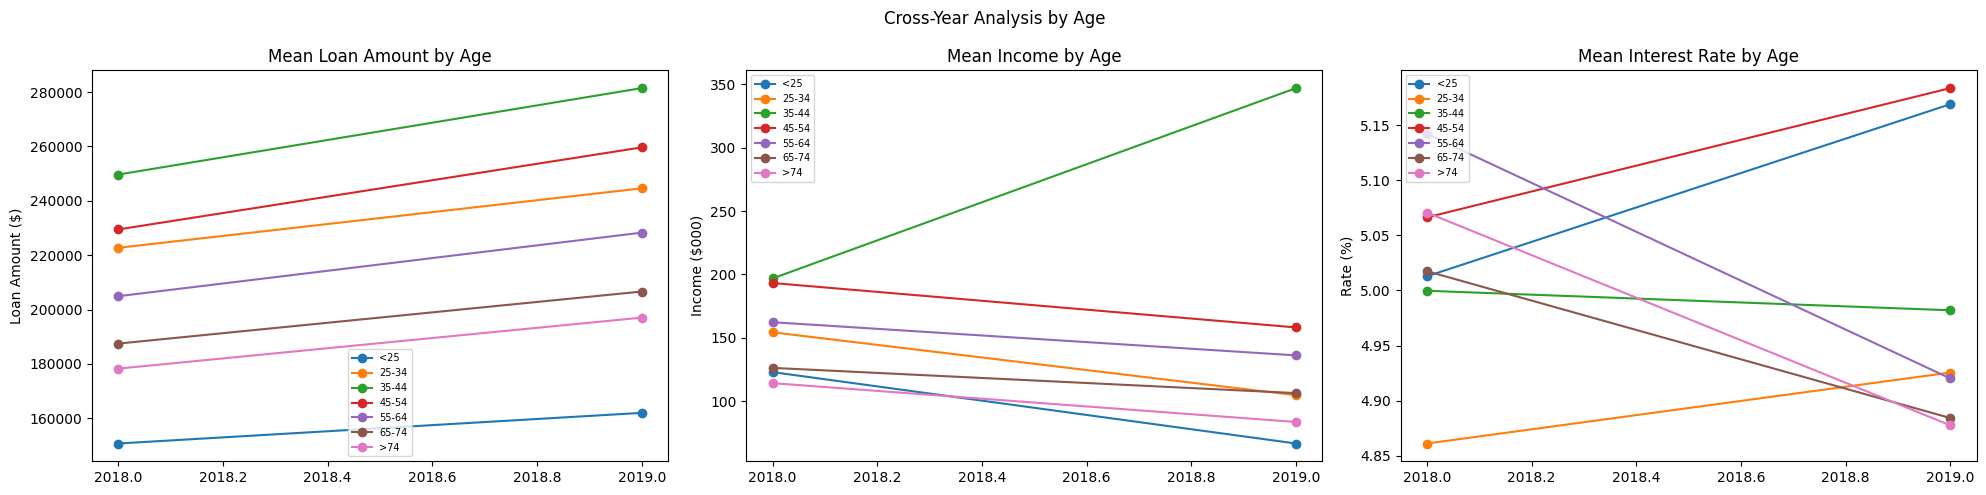

11053

In [8]:
rows_age = []

COLS_NEEDED_AGE = ["applicant_age", "action_taken",
                   "loan_amount", "income", "interest_rate"]

age_order = ["<25", "25-34", "35-44", "45-54", "55-64", "65-74", ">74"]

for y in available_years:
    out_path = os.path.join(output_dir, f"hmda_{y}.csv")

    df_y = pd.read_csv(out_path, usecols=COLS_NEEDED_AGE, low_memory=False)

    df_y["loan_amount"]   = pd.to_numeric(df_y["loan_amount"],   errors="coerce")
    df_y["income"]        = pd.to_numeric(df_y["income"],        errors="coerce")
    df_y["interest_rate"] = pd.to_numeric(df_y["interest_rate"], errors="coerce")
    df_y = df_y[(df_y["income"] > 0) & (df_y["loan_amount"] > 0)]

    for age in age_order:
        sub = df_y[df_y["applicant_age"] == age]
        if sub.empty:
            continue
        rows_age.append({
            "year":        y,
            "age":         age,
            "mean_loan":   sub["loan_amount"].mean(),
            "mean_income": sub["income"].mean(),
            "mean_rate":   sub["interest_rate"].mean(),
        })
    del df_y, sub; gc.collect()

cross_age = pd.DataFrame(rows_age)

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
fig.suptitle("Cross-Year Analysis by Age")

for age in age_order:
    sub = cross_age[cross_age["age"] == age]
    if sub.empty:
        continue
    axes[0].plot(sub["year"], sub["mean_loan"],   marker="o", label=age)
    axes[1].plot(sub["year"], sub["mean_income"], marker="o", label=age)
    axes[2].plot(sub["year"], sub["mean_rate"],   marker="o", label=age)

axes[0].set_title("Mean Loan Amount by Age")
axes[0].set_ylabel("Loan Amount ($)")
axes[0].legend(fontsize=7)

axes[1].set_title("Mean Income by Age")
axes[1].set_ylabel("Income ($000)")
axes[1].legend(fontsize=7)

axes[2].set_title("Mean Interest Rate by Age")
axes[2].set_ylabel("Rate (%)")
axes[2].legend(fontsize=7)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, "hmda_crossyear_age.png"), dpi=150)
plt.show()

del cross_age; gc.collect()

##**EDA 3** - Dataset with matching



Load Data...

In [ ]:
drive_root = "/content/drive/MyDrive/thesis_data"
output_dir = os.path.join(drive_root, "output")

COLS_NEEDED = [
    "derived_race", "derived_sex", "applicant_age", "income",
    "original_interest_rate", "credit_score",
    "original_ltv", "original_dti", "original_upb",
    # Categoriche
    "channel", "loan_purpose", "first_time_homebuyer_flag",
]

year = 2018
matched_path = os.path.join(output_dir, f"matched_{year}.csv")

df = pd.read_csv(matched_path, usecols=COLS_NEEDED, low_memory=False)

for col in ["original_interest_rate", "credit_score",
            "original_ltv", "original_dti"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Rimuovi sentinel values
df["credit_score"] = df["credit_score"].replace(9999, np.nan)
df["original_dti"] = df["original_dti"].replace(999,  np.nan)
df["original_ltv"] = df["original_ltv"].replace(999,  np.nan)

Analyzing the Data and Checking Missing Values...

In [ ]:
available_years=[2018,2019,2020,2021,2022,2023,2024]
for year in available_years:
  print(f"============ Analyzing file related to {year} ============ ")
  out_path = os.path.join(output_dir, f"panel_{year}.csv")
  df= pd.read_csv(out_path)
  print(f"Shape:{df.shape} (#rows x #columns)")
  print(" ")
  print("Data Type")
  print(df.dtypes)
  print(df.describe().T)
  print(" ")
  print("Checking Missing Values:")
  print(df.isnull().sum())
  print(f" ")

============ Analyzing file related to 2018 ============ 


/tmp/ipykernel_1170/4044106972.py:9: DtypeWarning: Columns (1,3,4,5,6,11,12,13,14,15,16,17,27,30,31,44,45,46,77,88,90,91,92,93) have mixed types. Specify dtype option on import or set low_memory=False.
  df= pd.read_csv(out_path)


Shape:(1426393, 115) (#rows x #columns)
 
Data Type
loan_sequence_number                  object
period_quarter                        object
period_year                          float64
monthly_reporting_period              object
loan_age                              object
                                      ...   
tract_to_msa_income_percentage       float64
tract_owner_occupied_units           float64
tract_one_to_four_family_homes       float64
tract_median_age_of_housing_units    float64
occupancy_status                      object
Length: 115, dtype: object
                                       count           mean            std  \
period_year                        1426392.0  167274.895280  119989.099278   
current_interest_rate                90698.0       3.314000       2.977409   
estimated_ltv                        90699.0   54745.406068   89694.998359   
current_deferred_upb               1426391.0       8.869300     264.565220   
current_loan_delinquency_status    1

/tmp/ipykernel_1170/4044106972.py:9: DtypeWarning: Columns (1,3,6,8,10,11,12,13,14,15,17,23,24,25,27,29,39,43,44,45,46,55,58,60,63,71,77,104) have mixed types. Specify dtype option on import or set low_memory=False.
  df= pd.read_csv(out_path)


Shape:(1843026, 114) (#rows x #columns)
 
Data Type
loan_sequence_number                  object
period_quarter                        object
period_year                          float64
monthly_reporting_period              object
loan_age                             float64
                                      ...   
tract_to_msa_income_percentage       float64
tract_owner_occupied_units           float64
tract_one_to_four_family_homes       float64
tract_median_age_of_housing_units    float64
occupancy_status                      object
Length: 114, dtype: object
                                       count           mean            std  \
period_year                        1843026.0  155859.703044  136613.153798   
loan_age                           1843025.0      28.038138      21.246965   
remaining_months_to_maturity       1843026.0     274.038778      85.641144   
current_interest_rate               427589.0       4.537805       1.570903   
current_deferred_upb               1

/tmp/ipykernel_1170/4044106972.py:9: DtypeWarning: Columns (10,11,14,15,43,45) have mixed types. Specify dtype option on import or set low_memory=False.
  df= pd.read_csv(out_path)


Bivariate Analysis...

In [3]:
year=2018
drive_root="/content/drive/MyDrive/thesis_data"
output_dir    = os.path.join(drive_root, "output")

out_path = os.path.join(output_dir, f"panel_{year}.csv")
panel= pd.read_csv(out_path)

print(f"Analysis related to {year}" )

/tmp/ipykernel_2800/3284351962.py:6: DtypeWarning: Columns (1,3,4,5,6,11,12,13,14,15,16,17,27,30,31,44,45,46,77,88,90,91,92,93) have mixed types. Specify dtype option on import or set low_memory=False.
  panel= pd.read_csv(out_path)


Analysis related to 2018


/tmp/ipykernel_2800/3188012906.py:29: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: (x["current_loan_delinquency_status"] > 0)


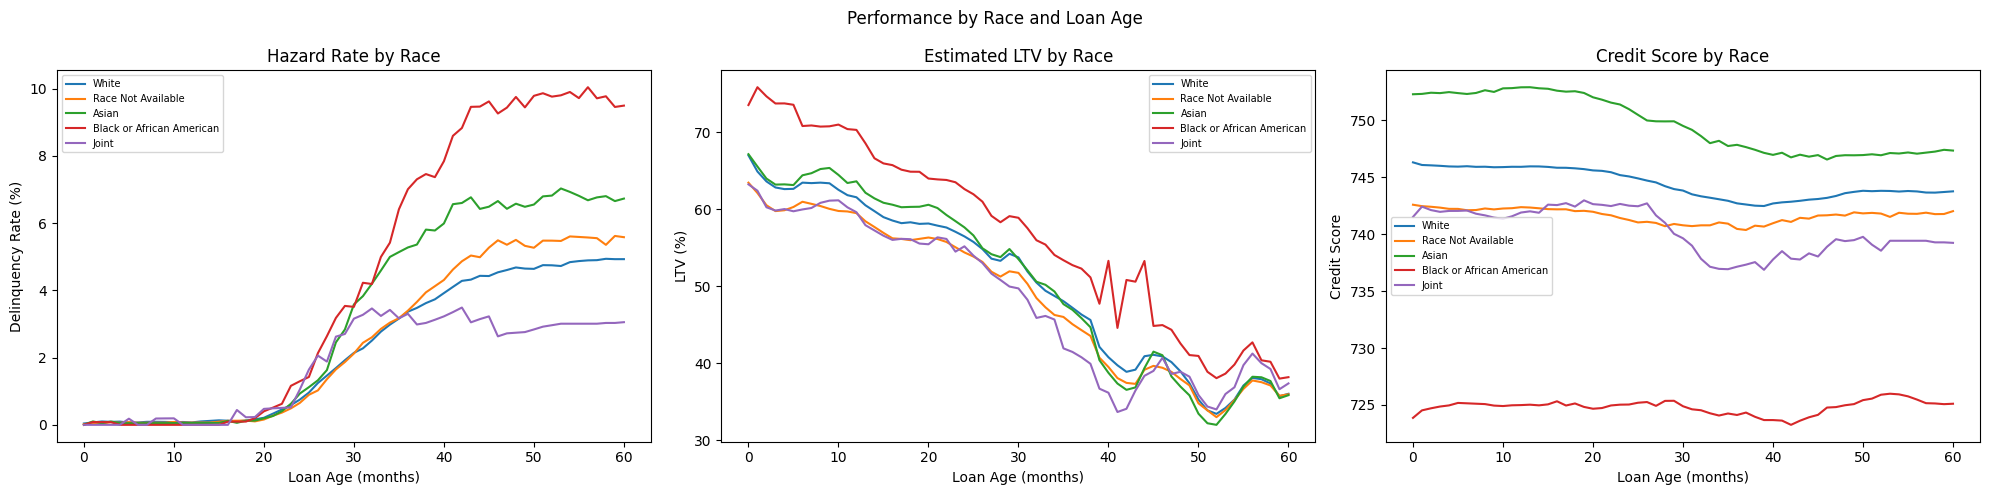

11365

In [7]:
top_races = panel["derived_race"].value_counts().head(5).index
panel_top = panel[panel["derived_race"].isin(top_races)].copy()


panel_top["estimated_ltv"] = pd.to_numeric(
    panel_top["estimated_ltv"], errors="coerce")
panel_top["estimated_ltv"] = panel_top["estimated_ltv"].replace(999, np.nan)

panel_top.loc[panel_top["estimated_ltv"] > 200, "estimated_ltv"] = np.nan

panel_top["current_loan_delinquency_status"] = pd.to_numeric(
    panel_top["current_loan_delinquency_status"], errors="coerce")

panel_top["credit_score"] = pd.to_numeric(
    panel_top["credit_score"], errors="coerce")
panel_top["credit_score"] = panel_top["credit_score"].replace(9999, np.nan)


panel_top["loan_age"] = pd.to_numeric(panel_top["loan_age"], errors="coerce")
panel_top = panel_top[panel_top["loan_age"] <= 60]

ltv_agg = panel_top.groupby(["loan_age", "derived_race"])["estimated_ltv"]\
                   .mean().reset_index()

haz_agg = panel_top.groupby(["loan_age", "derived_race"])\
                   .apply(lambda x: (x["current_loan_delinquency_status"] > 0)
                   .mean() * 100).reset_index(name="hazard_rate")

cs_agg  = panel_top.groupby(["loan_age", "derived_race"])["credit_score"]\
                   .mean().reset_index()

del panel_top; gc.collect()


fig, axes = plt.subplots(1, 3, figsize=(20, 5))
fig.suptitle("Performance by Race and Loan Age")

for race in top_races:
    sub_h = haz_agg[haz_agg["derived_race"] == race]
    sub_l = ltv_agg[ltv_agg["derived_race"] == race]
    sub_c = cs_agg[cs_agg["derived_race"]  == race]

    axes[0].plot(sub_h["loan_age"], sub_h["hazard_rate"],   label=race)
    axes[1].plot(sub_l["loan_age"], sub_l["estimated_ltv"], label=race)
    axes[2].plot(sub_c["loan_age"], sub_c["credit_score"],  label=race)

axes[0].set_title("Hazard Rate by Race")
axes[0].set_xlabel("Loan Age (months)")
axes[0].set_ylabel("Delinquency Rate (%)")
axes[0].legend(fontsize=7)

axes[1].set_title("Estimated LTV by Race")
axes[1].set_xlabel("Loan Age (months)")
axes[1].set_ylabel("LTV (%)")
axes[1].legend(fontsize=7)

axes[2].set_title("Credit Score by Race")
axes[2].set_xlabel("Loan Age (months)")
axes[2].set_ylabel("Credit Score")
axes[2].legend(fontsize=7)

plt.tight_layout()
plt.show()

del ltv_agg, haz_agg, cs_agg; gc.collect()

/tmp/ipykernel_2800/2862403301.py:25: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: (x["current_loan_delinquency_status"] >= 3)


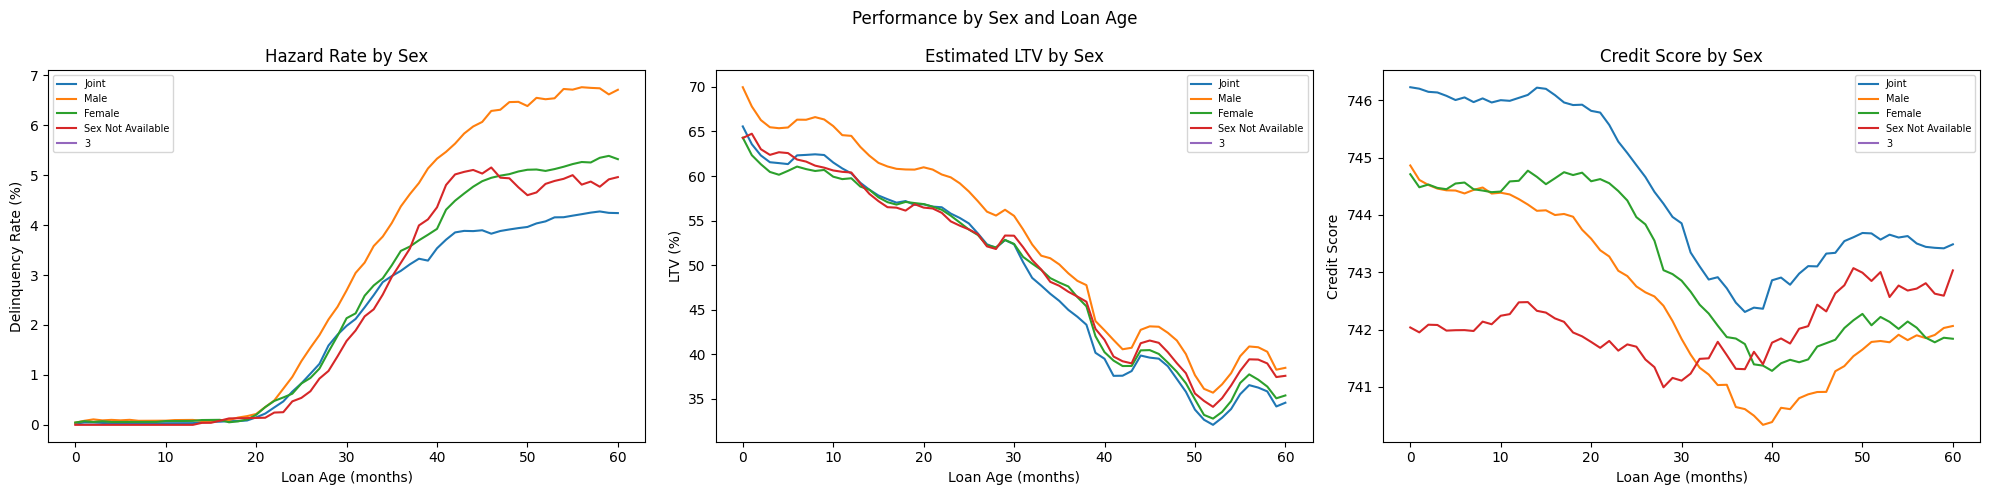

11454

In [8]:
top_sex = panel["derived_sex"].value_counts().index
panel_sex = panel[panel["derived_sex"].isin(top_sex)].copy()


panel_sex["estimated_ltv"] = pd.to_numeric(
    panel_sex["estimated_ltv"], errors="coerce")
panel_sex["estimated_ltv"] = panel_sex["estimated_ltv"].replace(999, np.nan)
panel_sex.loc[panel_sex["estimated_ltv"] > 200, "estimated_ltv"] = np.nan

panel_sex["current_loan_delinquency_status"] = pd.to_numeric(
    panel_sex["current_loan_delinquency_status"], errors="coerce")

panel_sex["credit_score"] = pd.to_numeric(
    panel_sex["credit_score"], errors="coerce")
panel_sex["credit_score"] = panel_sex["credit_score"].replace(9999, np.nan)

panel_sex["loan_age"] = pd.to_numeric(panel_sex["loan_age"], errors="coerce")
panel_sex = panel_sex[panel_sex["loan_age"] <= 60]


ltv_agg = panel_sex.groupby(["loan_age", "derived_sex"])["estimated_ltv"]\
                   .mean().reset_index()

haz_agg = panel_sex.groupby(["loan_age", "derived_sex"])\
                   .apply(lambda x: (x["current_loan_delinquency_status"] >= 3)
                   .mean() * 100).reset_index(name="hazard_rate")

cs_agg  = panel_sex.groupby(["loan_age", "derived_sex"])["credit_score"]\
                   .mean().reset_index()

del panel_sex; gc.collect()

# Plot
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
fig.suptitle("Performance by Sex and Loan Age")

for sex in top_sex:
    sub_h = haz_agg[haz_agg["derived_sex"] == sex]
    sub_l = ltv_agg[ltv_agg["derived_sex"] == sex]
    sub_c = cs_agg[cs_agg["derived_sex"]   == sex]

    axes[0].plot(sub_h["loan_age"], sub_h["hazard_rate"],   label=sex)
    axes[1].plot(sub_l["loan_age"], sub_l["estimated_ltv"], label=sex)
    axes[2].plot(sub_c["loan_age"], sub_c["credit_score"],  label=sex)

axes[0].set_title("Hazard Rate by Sex")
axes[0].set_xlabel("Loan Age (months)")
axes[0].set_ylabel("Delinquency Rate (%)")
axes[0].legend(fontsize=7)

axes[1].set_title("Estimated LTV by Sex")
axes[1].set_xlabel("Loan Age (months)")
axes[1].set_ylabel("LTV (%)")
axes[1].legend(fontsize=7)

axes[2].set_title("Credit Score by Sex")
axes[2].set_xlabel("Loan Age (months)")
axes[2].set_ylabel("Credit Score")
axes[2].legend(fontsize=7)

plt.tight_layout()
plt.show()

del ltv_agg, haz_agg, cs_agg; gc.collect()

/tmp/ipykernel_2800/3967837328.py:26: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: (x["current_loan_delinquency_status"] >= 3)


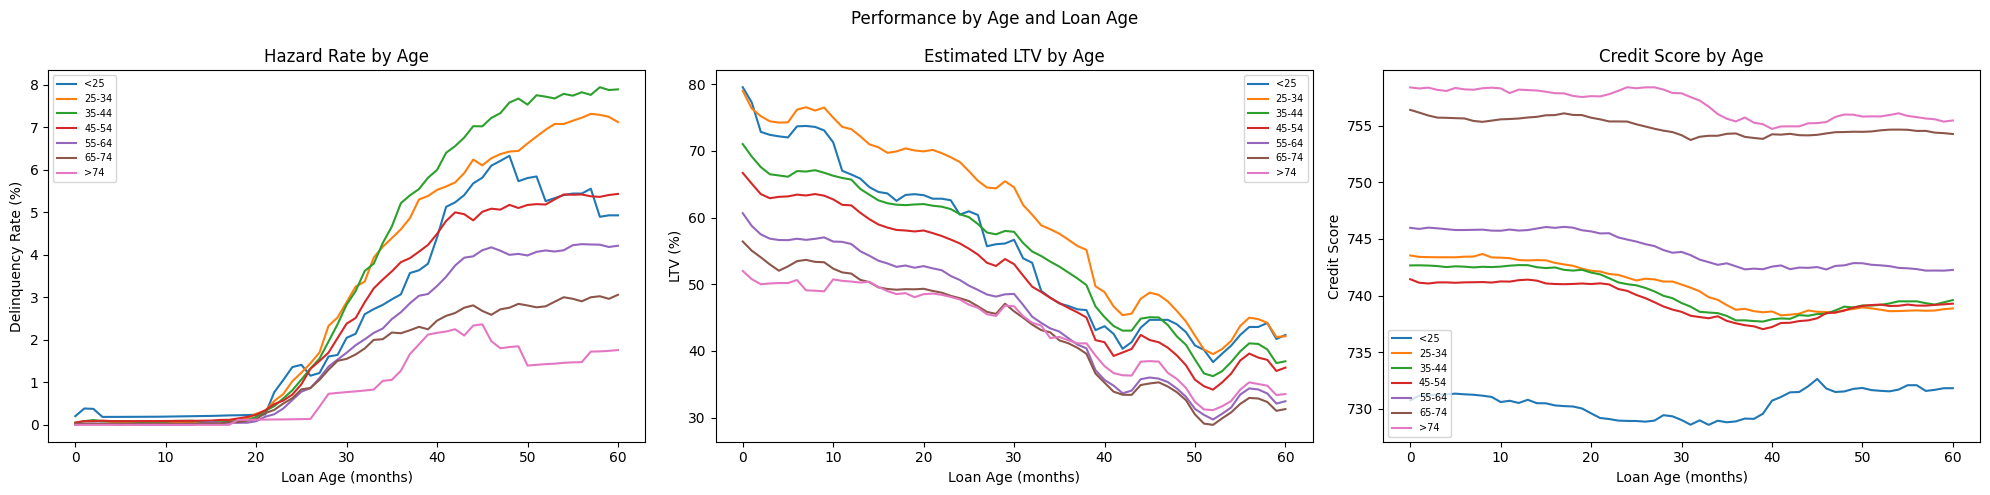

11966

In [9]:
age_order = ["<25", "25-34", "35-44", "45-54", "55-64", "65-74", ">74"]

panel_age = panel[panel["applicant_age"].isin(age_order)].copy()


panel_age["estimated_ltv"] = pd.to_numeric(
    panel_age["estimated_ltv"], errors="coerce")
panel_age["estimated_ltv"] = panel_age["estimated_ltv"].replace(999, np.nan)
panel_age.loc[panel_age["estimated_ltv"] > 200, "estimated_ltv"] = np.nan

panel_age["current_loan_delinquency_status"] = pd.to_numeric(
    panel_age["current_loan_delinquency_status"], errors="coerce")

panel_age["credit_score"] = pd.to_numeric(
    panel_age["credit_score"], errors="coerce")
panel_age["credit_score"] = panel_age["credit_score"].replace(9999, np.nan)

panel_age["loan_age"] = pd.to_numeric(panel_age["loan_age"], errors="coerce")
panel_age = panel_age[panel_age["loan_age"] <= 60]


ltv_agg = panel_age.groupby(["loan_age", "applicant_age"])["estimated_ltv"]\
                   .mean().reset_index()

haz_agg = panel_age.groupby(["loan_age", "applicant_age"])\
                   .apply(lambda x: (x["current_loan_delinquency_status"] >= 3)
                   .mean() * 100).reset_index(name="hazard_rate")

cs_agg  = panel_age.groupby(["loan_age", "applicant_age"])["credit_score"]\
                   .mean().reset_index()

del panel_age; gc.collect()

# Plot
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
fig.suptitle("Performance by Age and Loan Age")

for age in age_order:
    sub_h = haz_agg[haz_agg["applicant_age"] == age]
    sub_l = ltv_agg[ltv_agg["applicant_age"] == age]
    sub_c = cs_agg[cs_agg["applicant_age"]   == age]

    if sub_h.empty:
        continue

    axes[0].plot(sub_h["loan_age"], sub_h["hazard_rate"],   label=age)
    axes[1].plot(sub_l["loan_age"], sub_l["estimated_ltv"], label=age)
    axes[2].plot(sub_c["loan_age"], sub_c["credit_score"],  label=age)

axes[0].set_title("Hazard Rate by Age")
axes[0].set_xlabel("Loan Age (months)")
axes[0].set_ylabel("Delinquency Rate (%)")
axes[0].legend(fontsize=7)

axes[1].set_title("Estimated LTV by Age")
axes[1].set_xlabel("Loan Age (months)")
axes[1].set_ylabel("LTV (%)")
axes[1].legend(fontsize=7)

axes[2].set_title("Credit Score by Age")
axes[2].set_xlabel("Loan Age (months)")
axes[2].set_ylabel("Credit Score")
axes[2].legend(fontsize=7)

plt.tight_layout()
plt.show()

del ltv_agg, haz_agg, cs_agg; gc.collect()

Multivariate Analysis...

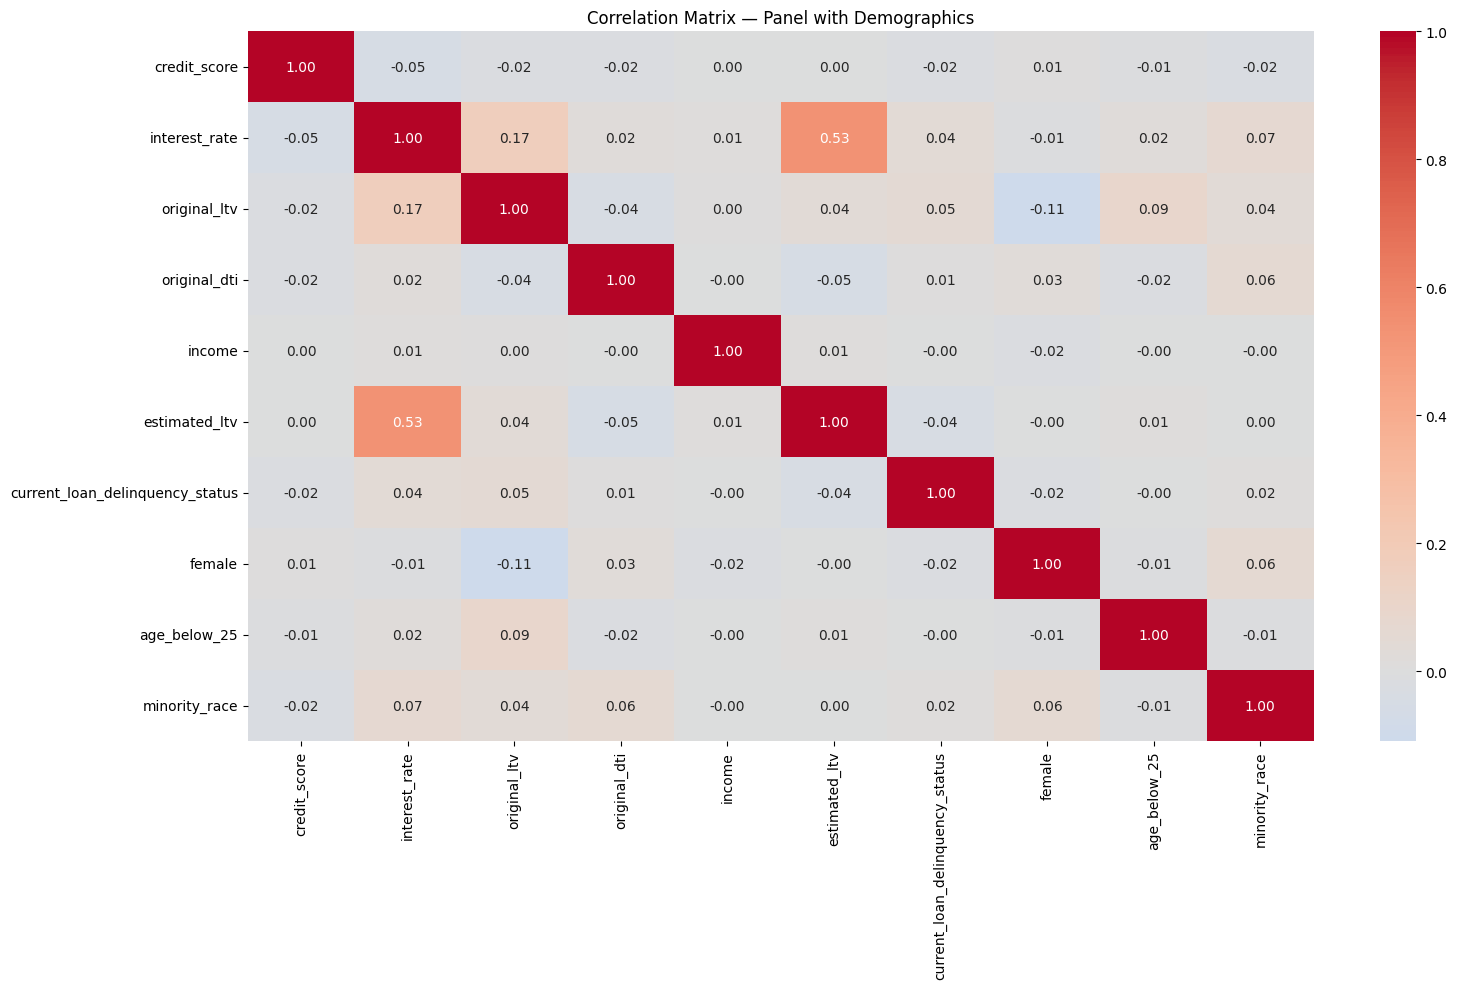

33330

In [13]:
df_corr = panel[num_cols].apply(pd.to_numeric, errors="coerce")


df_corr["female"] = panel["derived_sex"].map({
    "Female": 1,
    "Male":   0
})


df_corr["age_below_25"] = (panel["applicant_age"] == "<25").astype(int)


df_corr["minority_race"] = panel["derived_race"].isin([
    "Black or African American",
    "American Indian or Alaska Native"
]).astype(int)

corr = df_corr.corr()

fig, ax = plt.subplots(figsize=(16, 10))
sns.heatmap(corr, annot=True, fmt=".2f",
            cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlation Matrix — Panel with Demographics")
plt.tight_layout()
plt.show()

del df_corr; gc.collect()

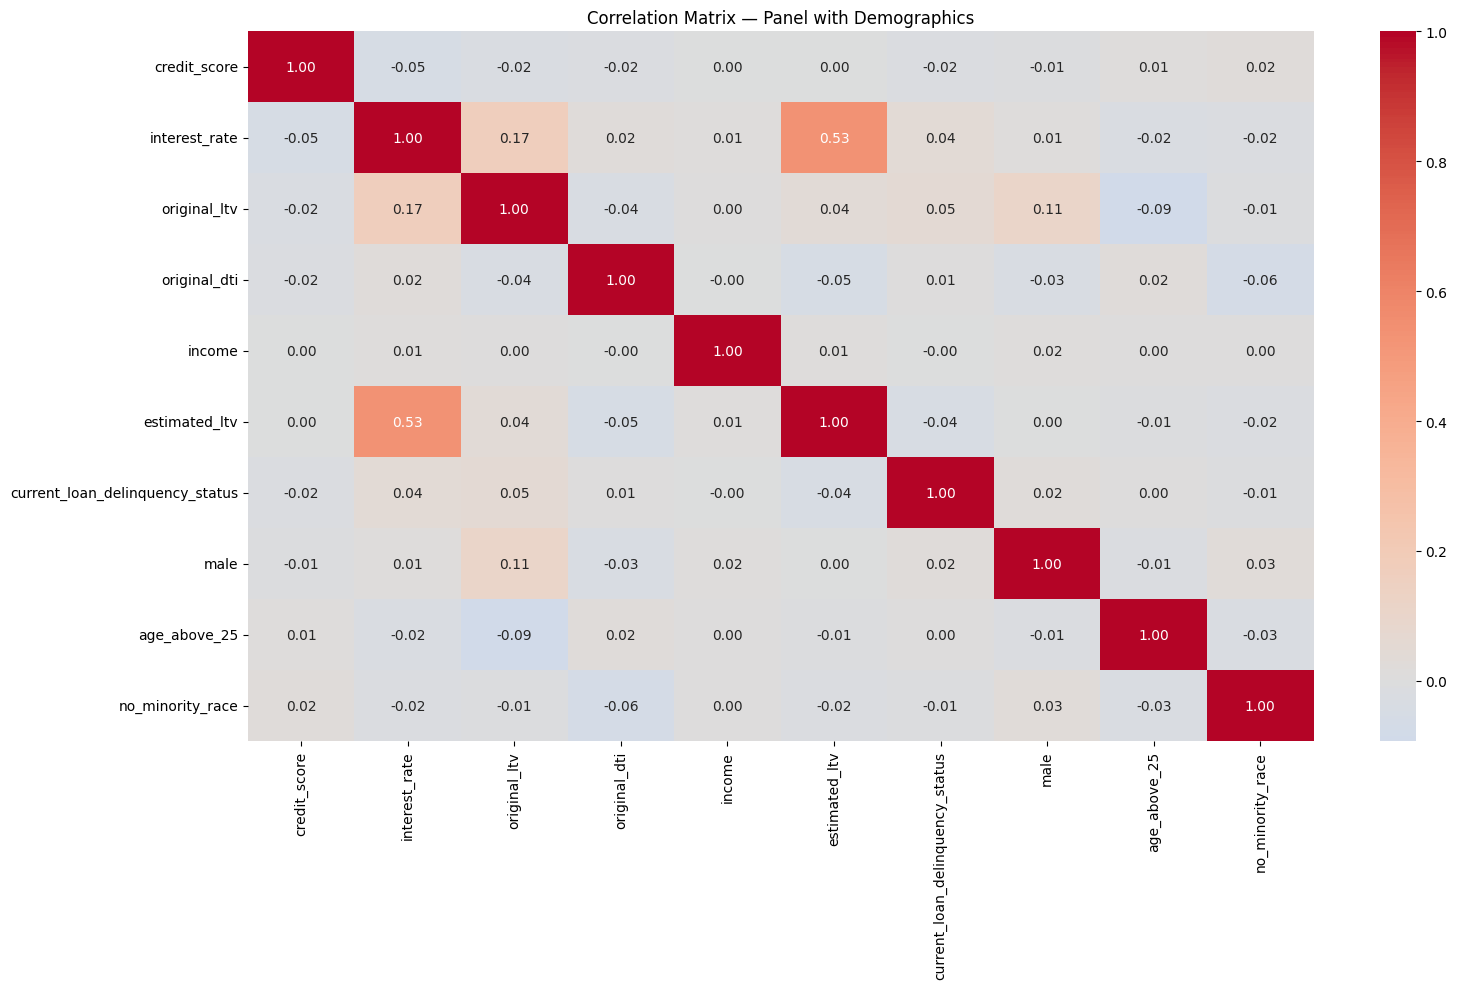

11191

In [15]:
df_corr = panel[num_cols].apply(pd.to_numeric, errors="coerce")


df_corr["male"] = panel["derived_sex"].map({
    "Female": 0,
    "Male":   1
})


df_corr["age_above_25"] = (panel["applicant_age"] != "<25").astype(int)


df_corr["no_minority_race"] = panel["derived_race"].isin([
    "White",
    "Asian"
]).astype(int)

corr = df_corr.corr()

fig, ax = plt.subplots(figsize=(16, 10))
sns.heatmap(corr, annot=True, fmt=".2f",
            cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlation Matrix — Panel with Demographics")
plt.tight_layout()
plt.show()

del df_corr; gc.collect()

##**Matching Analysis**

  Year: 2018

--- MATCH RATE ---
Freddie TOT  : 1,103,972
Freddie MATCHED: 33,585
Match rate      : 3.04%

--- KS TEST FREDDIE ---


,variable,mean_matched,mean_freddie,diff_pct,ks_stat,ks_p,flag
0,credit_score,745.54,746.26,-0.10,0.0235,4.05e-16,X
1,original_ltv,66.86,76.23,-12.30,0.2925,0.00e+00,X
2,original_dti,35.29,35.84,-1.53,0.0237,4.39e-16,X


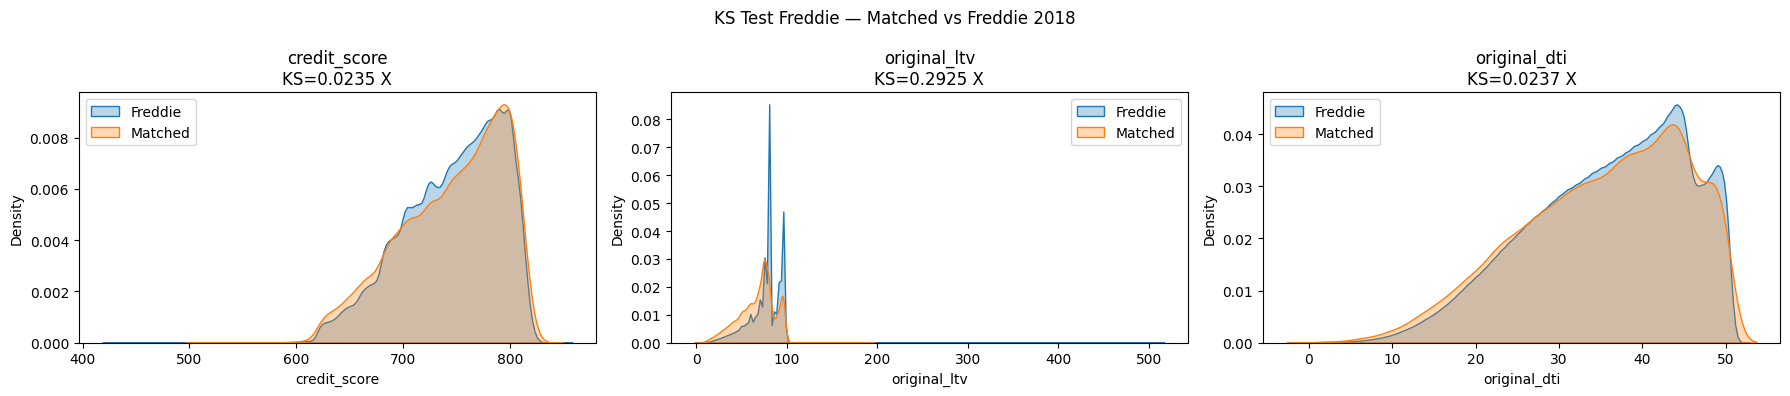

In [ ]:
from scipy.stats import ks_2samp

OUTPUT_DIR="/content/drive/MyDrive/thesis_data/output"

def run_evaluation(year: int):

    CHUNK_SIZE   = 200_000
    MAX_HMDA_REF = 1_000_000

    matched_path = os.path.join(OUTPUT_DIR, f"matched_{year}.csv")
    hmda_path    =os.path.join(OUTPUT_DIR, f"hmda_{year}.csv")
    freddie_path = os.path.join(OUTPUT_DIR, f"freddie_{year}.csv")

    print(f"  Year: {year}")


    freddie = pd.read_csv(freddie_path, low_memory=False)
    df      = pd.read_csv(matched_path, low_memory=False)


    print("\n--- MATCH RATE ---")
    n_freddie = len(freddie)
    n_matched = df["loan_sequence_number"].nunique()
    print(f"Freddie TOT  : {n_freddie:,}")
    print(f"Freddie MATCHED: {n_matched:,}")
    print(f"Match rate      : {100 * n_matched / n_freddie:.2f}%")



    print("\n--- KS TEST FREDDIE ---")
    FREDDIE_COLS = ["credit_score", "original_ltv", "original_dti"]
    rows_f = []

    for col in FREDDIE_COLS:
        if col not in df.columns or col not in freddie.columns:
            continue
        m = pd.to_numeric(df[col],      errors="coerce").dropna()
        f = pd.to_numeric(freddie[col], errors="coerce").dropna()
        f = f[~f.isin([999, 9999])]
        m = m[~m.isin([999, 9999])]
        ks, p = ks_2samp(m, f)
        rows_f.append({
            "variable":     col,
            "mean_matched": round(m.mean(), 2),
            "mean_freddie": round(f.mean(), 2),
            "diff_pct":     round((m.mean() - f.mean()) / f.mean() * 100, 2),
            "ks_stat":      round(ks, 4),
            "ks_p":         f"{p:.2e}",
            "flag":         "X" if p < 0.05 else "OK",
        })

    display(pd.DataFrame(rows_f))




    fig, axes = plt.subplots(1, len(rows_f), figsize=(6*len(rows_f), 4))
    if len(rows_f) == 1: axes = [axes]
    fig.suptitle(f"KS Test Freddie — Matched vs Freddie {year}")
    for ax, row in zip(axes, rows_f):
        col = row["variable"]
        m   = pd.to_numeric(df[col],      errors="coerce").dropna()
        f   = pd.to_numeric(freddie[col], errors="coerce").dropna()
        f   = f[~f.isin([999, 9999])]
        m   = m[~m.isin([999, 9999])]
        sns.kdeplot(f, ax=ax, label="Freddie", fill=True, alpha=0.3)
        sns.kdeplot(m, ax=ax, label="Matched", fill=True, alpha=0.3)
        ax.set_title(f"{col}\nKS={row['ks_stat']} {row['flag']}")
        ax.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, f"ks_freddie_{year}.png"), dpi=150)
    plt.show()

    del freddie; gc.collect()

    chunks_ref  = []
    rows_so_far = 0
    HMDA_COLS   = ["derived_race", "derived_sex", "applicant_age"]

    for chunk in pd.read_csv(hmda_path, dtype=str,
                            chunksize=CHUNK_SIZE, low_memory=False):
        chunk.rename(columns=lambda c: c.replace("-", "_"), inplace=True)
        mask = ((chunk["purchaser_type"] == "3") &
                (chunk["action_taken"]   == "1"))
        sub  = chunk.loc[mask, [c for c in HMDA_COLS if c in chunk.columns]]
        if not sub.empty:
            chunks_ref.append(sub)
            rows_so_far += len(sub)
        if rows_so_far >= MAX_HMDA_REF:
            break
        del chunk, sub; gc.collect()

    hmda_ref = pd.concat(chunks_ref, ignore_index=True)
    del chunks_ref; gc.collect()


    print()
    print("\n--- DEMOGRAPHIC DISTRIBUTION HMDA ---")
    for col in ["derived_race", "derived_sex", "applicant_age"]:
        if col not in hmda_ref.columns or col not in df.columns:
            continue
        comp = pd.DataFrame({
            "HMDA %":    hmda_ref[col].value_counts(normalize=True) * 100,
            "Matched %": df[col].value_counts(normalize=True) * 100,
        }).fillna(0)
        comp["Diff (pp)"] = (comp["Matched %"] - comp["HMDA %"]).round(2)
        print(f"\n{col}:")
        print(comp.round(2))

    del hmda_ref, df; gc.collect()



for year in [2018, 2019, 2020, 2021, 2022, 2023, 2024]:
    run_evaluation(year)
    gc.collect()